# Mass Model Diagnostics

Fills the gaps in the analysis plan, using only the trained baseline in
`outputs/mass_model/2xlayers_b32/`. Sections map to the plan:

- **A. Age recovery** — per-cluster table, test-vs-val agreement, multi-level coverage curve, posterior width vs input σ.
- **B. Density plots** — fixed-mass heatmap with training-data overlay.
- **C. Sample posterior** — width-vs-residual honesty check, bimodal-posterior examples.
- **D. Binarity** — residual + width split by RUWE, Jao-gap zoom, RUWE-split precision/accuracy.
- **E. Discussion** — predicted vs observed fast-rotator fraction per training cluster.

In [4]:
import sys
sys.path.insert(0, '../..')

import os, pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats  import spearmanr

from training.constants import LOGA_GRID
from training.data      import load_training, make_holdout_split
from training.flow      import create_flow
from training.infer     import batch_posteriors
from training.metrics   import compute_residuals, compute_coverage
from training.plots     import set_paper_style, plot_precision_grid, plot_accuracy_grid

set_paper_style()

OBS_COL         = 'log_prot'
COND_COLS       = ['log_age_myr', 'mass_msun', 'mass_msun_err_lo', 'mass_msun_err_hi']
HIDDEN_FEATURES = (64, 64, 64, 64)
MODEL_DIR       = '../../outputs/mass_model/2xlayers_b32'
N_FOLDS         = 5

## 0. Load data + saved fold flows

In [5]:
df = load_training('../../cf_data/training_stars.csv', drop_nan_age_err=False)
train_val_df, test_df = make_holdout_split(df, test_frac=0.10)

flows, scalers = [], []
for i in range(N_FOLDS):
    flow = create_flow(n_cond=len(COND_COLS), hidden_features=HIDDEN_FEATURES)
    flow.load_state_dict(torch.load(f'{MODEL_DIR}/fold{i}_flow.pt'))
    flow.eval()
    flows.append(flow)
    with open(f'{MODEL_DIR}/fold{i}_scaler.pkl', 'rb') as f:
        scalers.append(pickle.load(f))

val_results    = pd.read_csv(f'{MODEL_DIR}/results.csv')
val_posteriors = np.load(f'{MODEL_DIR}/posteriors_kfold.npy')
print(f'Loaded {len(flows)} fold models; {len(val_results)} k-fold val rows; {len(test_df)} test rows.')

Loaded 5 fold models; 5515 k-fold val rows; 613 test rows.


## 0b. Test-set posteriors — ensemble across folds

Each fold model was trained on a different 80% of the train/val pool but never saw the test set. Averaging gives a single test posterior per star.

In [6]:
test_post_per_fold = [batch_posteriors(f, test_df, OBS_COL, COND_COLS, s)
                      for f, s in zip(flows, scalers)]
test_posteriors = np.mean(test_post_per_fold, axis=0)
test_posteriors /= np.trapz(test_posteriors, LOGA_GRID, axis=1)[:, None]
test_results = compute_residuals(test_df, test_posteriors)
print(f'Test posteriors: shape {test_posteriors.shape}')

Test posteriors: shape (613, 1000)


# Section A — Age recovery

## A.1 Per-cluster recovery

In [7]:
per_cluster = (val_results.dropna(subset=['cluster_name'])
               .groupby('cluster_name')
               .agg(n=('residual_dex', 'size'),
                    true_log_age=('log_age_myr', 'median'),
                    median_p50=('p50', 'median'),
                    median_residual=('residual_dex', 'median'),
                    std_residual=('residual_dex', 'std'),
                    median_width=('p84', lambda s: float((val_results.loc[s.index, 'p84'] - val_results.loc[s.index, 'p16']).median())))
               .sort_values('true_log_age'))
print(f'{len(per_cluster)} clusters with named membership')
per_cluster.round(3)

42 clusters with named membership


,n,true_log_age,median_p50,median_residual,std_residual,median_width
cluster_name,,,,,,
ROph_L1688,38,0.568,1.186,0.617,0.436,1.922
Mamonova2025 (4.5 Myr),1,0.653,0.999,0.346,NaN,1.774
Mamonova2025 (5.0 Myr),4,0.699,1.831,1.132,0.527,2.086
NSco,20,0.778,1.091,0.313,0.415,2.080
BSco,28,0.895,1.267,0.372,0.427,1.950
R+18,43,1.006,1.187,0.359,0.391,1.772
DSco,94,1.006,1.158,0.151,0.423,1.886
SSco,53,1.011,1.188,0.177,0.470,1.801
Antares,36,1.102,1.164,0.062,0.488,1.823


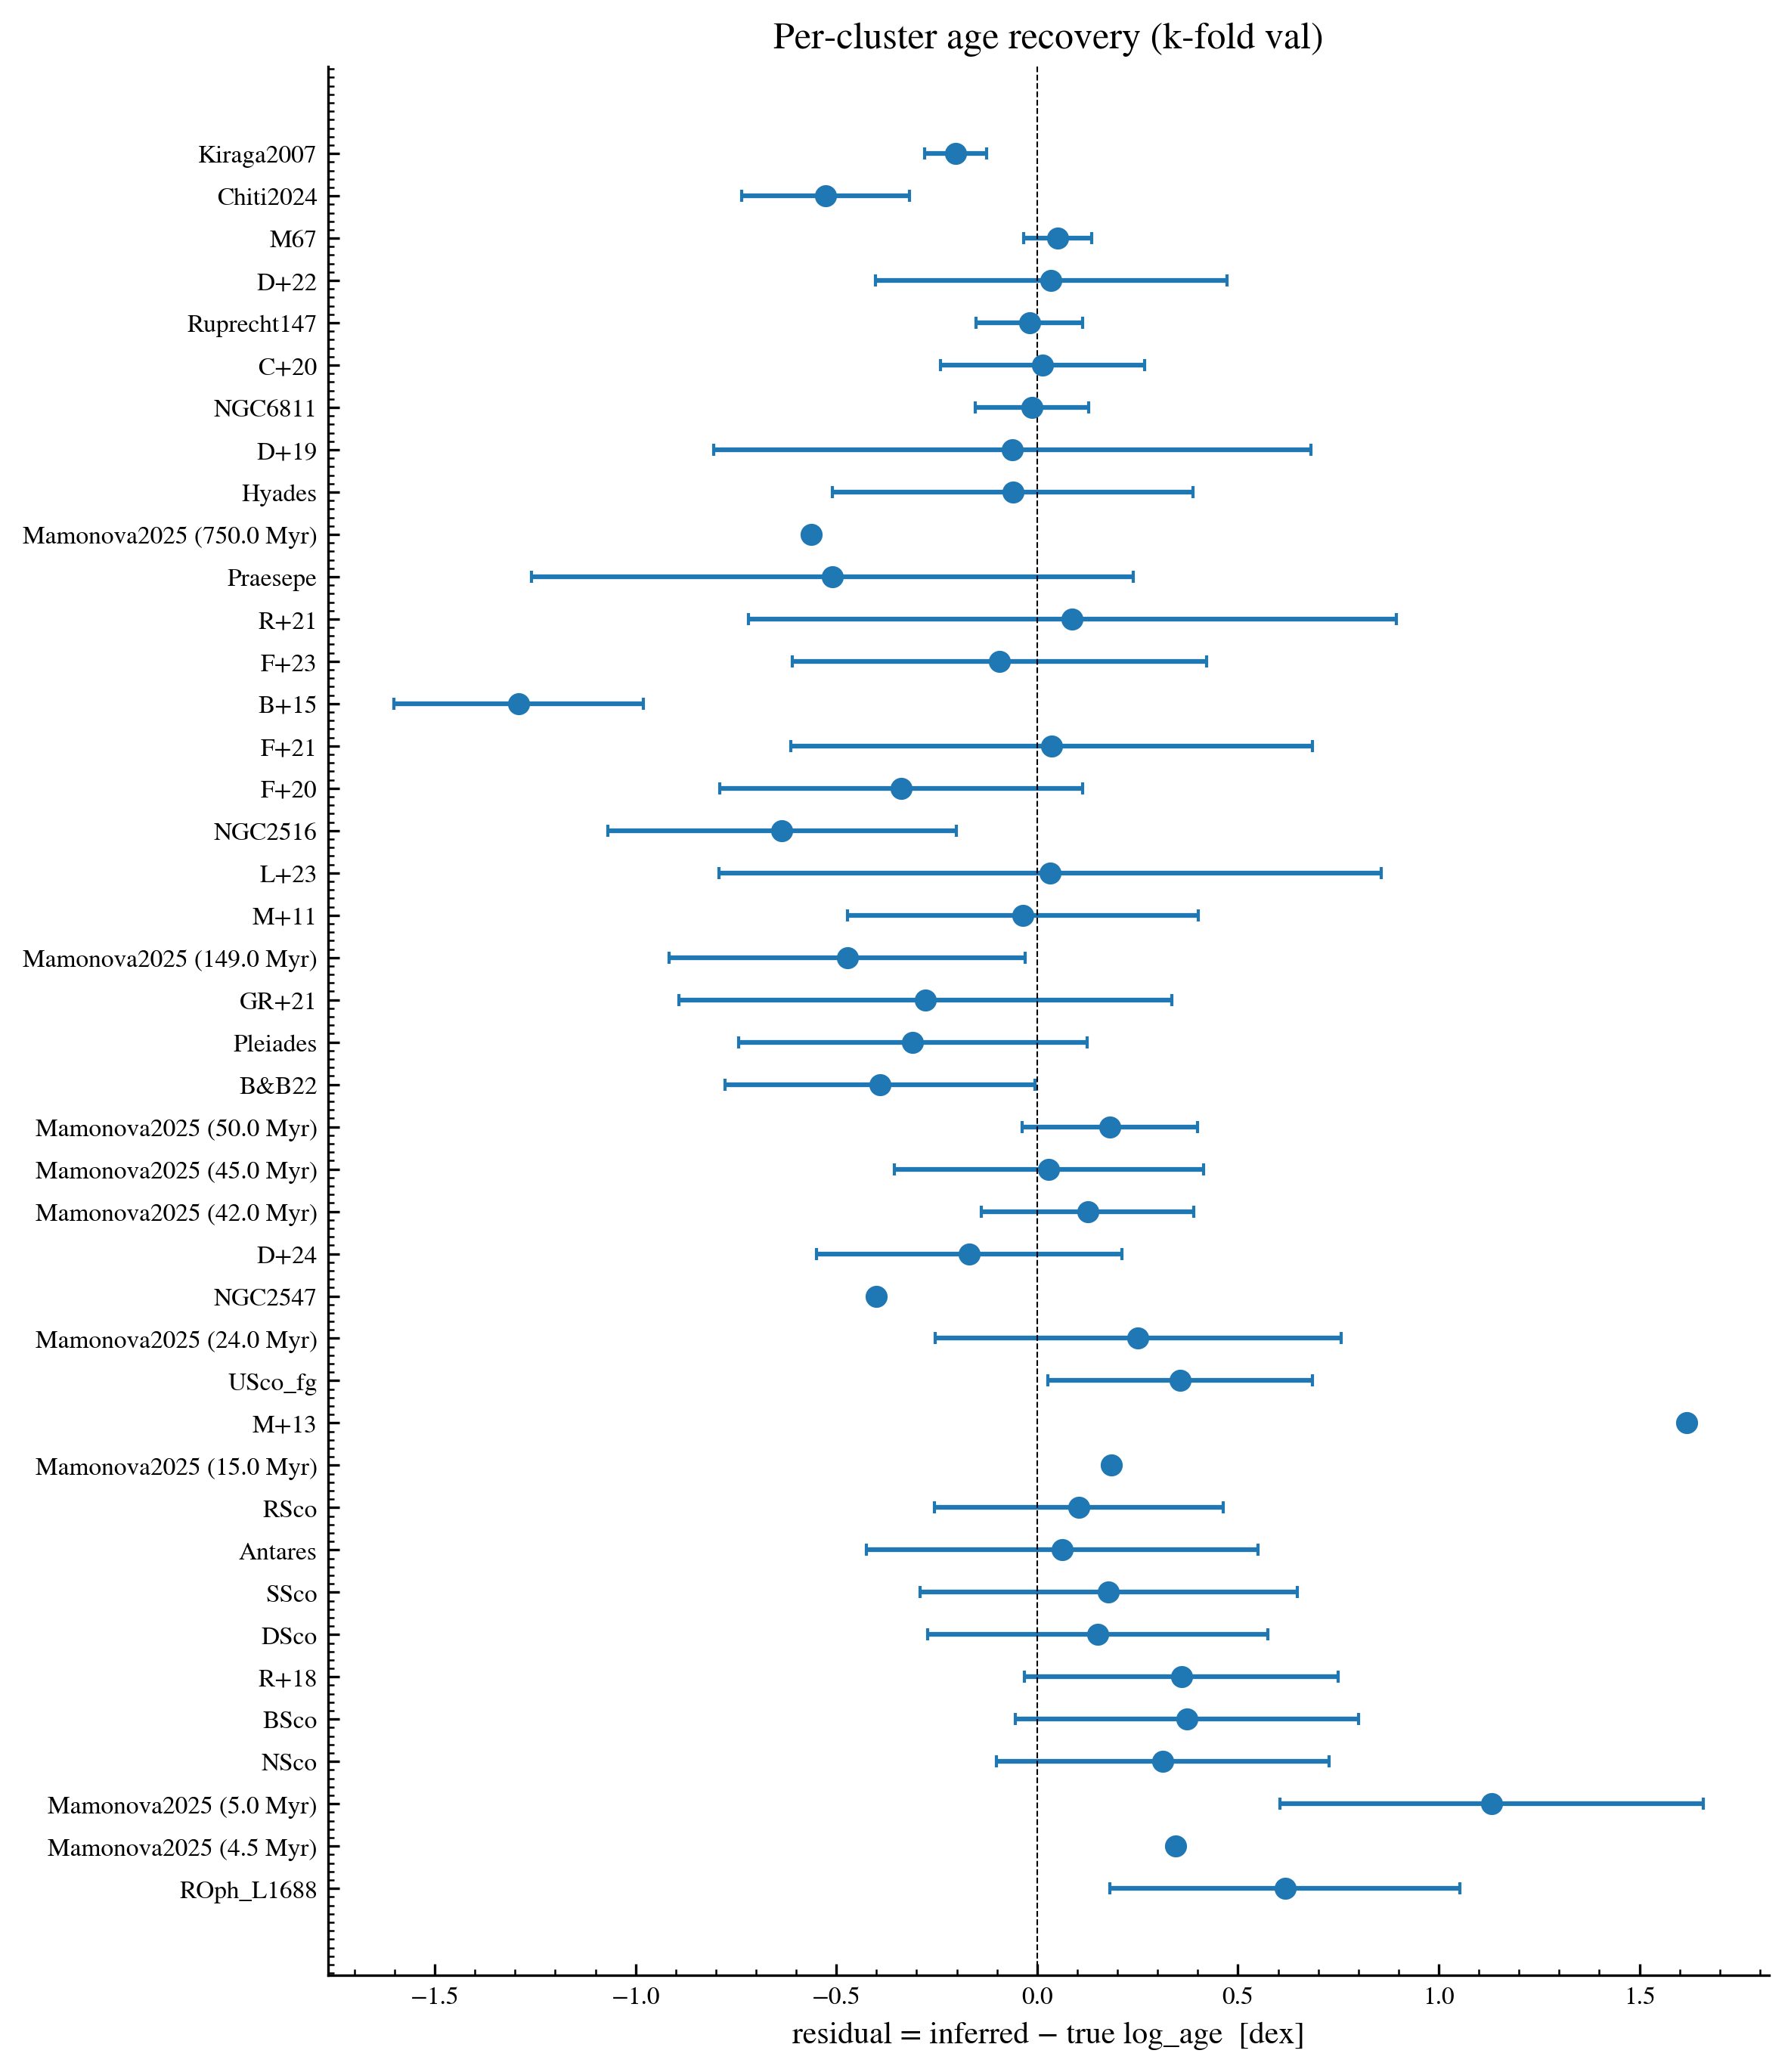

In [8]:
fig, ax = plt.subplots(figsize=(8, max(3.5, len(per_cluster) * 0.22)))
y = np.arange(len(per_cluster))
ax.errorbar(per_cluster['median_residual'], y, xerr=per_cluster['std_residual'],
            fmt='o', capsize=2)
ax.axvline(0, color='k', lw=0.5, ls='--')
ax.set_yticks(y); ax.set_yticklabels(per_cluster.index, fontsize=8)
ax.set_xlabel('residual = inferred − true log_age  [dex]')
ax.set_title('Per-cluster age recovery (k-fold val)')
plt.tight_layout(); plt.show()

## A.2 Test holdout vs k-fold val agreement

In [9]:
def summary(r, label):
    v = r[['residual_dex', 'p16', 'p50', 'p84', 'log_age_myr']].notna().all(axis=1)
    rv = r[v]
    inside = (rv['log_age_myr'] >= rv['p16']) & (rv['log_age_myr'] <= rv['p84'])
    return {
        'set'                 : label,
        'n'                   : len(rv),
        'median_residual'     : float(rv['residual_dex'].median()),
        'median_abs_residual' : float(rv['residual_dex'].abs().median()),
        'median_width'        : float((rv['p84'] - rv['p16']).median()),
        'frac_within_0.3_dex' : float((rv['residual_dex'].abs() < 0.3).mean()),
        'coverage_68'         : float(inside.mean()),
    }

pd.DataFrame([summary(val_results, 'kfold val'),
              summary(test_results, 'test holdout')]).set_index('set').round(4)

,n,median_residual,median_abs_residual,median_width,frac_within_0.3_dex,coverage_68
set,,,,,,
kfold val,5515,-0.2258,0.4389,1.9059,0.3819,0.8238
test holdout,613,-0.2480,0.3861,1.8924,0.4144,0.8532


## A.3 Multi-level posterior coverage

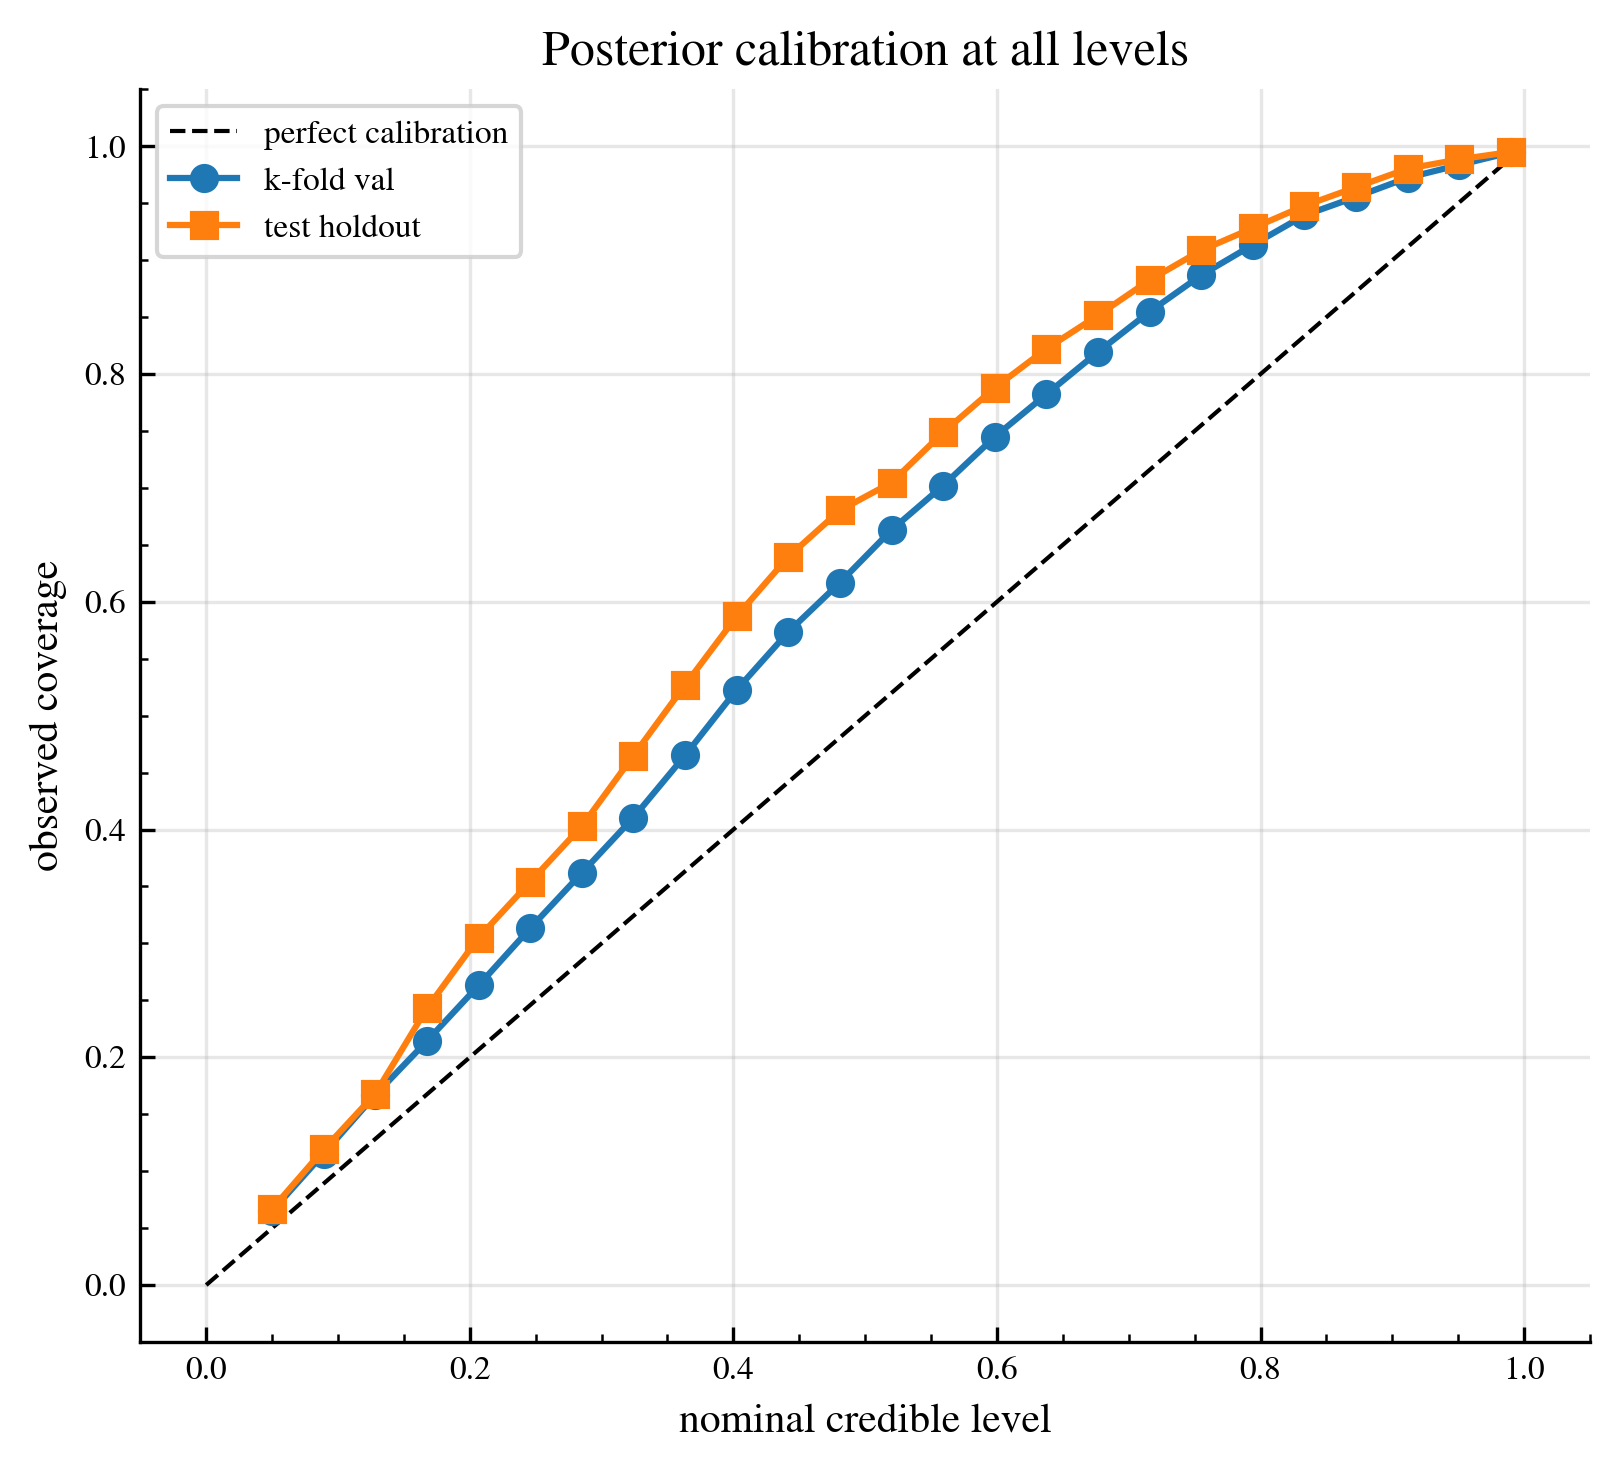

In [10]:
levels = np.linspace(0.05, 0.99, 25)

def cov_curve(rdf, posts):
    v   = rdf['log_age_myr'].notna()
    cov = compute_coverage(posts[v.values], rdf.loc[v, 'log_age_myr'].values, levels=tuple(levels))
    return np.array([cov[L] for L in levels])

cov_val  = cov_curve(val_results,  val_posteriors)
cov_test = cov_curve(test_results, test_posteriors)

plt.figure(figsize=(5.5, 5))
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='perfect calibration')
plt.plot(levels, cov_val,  'o-', label='k-fold val')
plt.plot(levels, cov_test, 's-', label='test holdout')
plt.xlabel('nominal credible level')
plt.ylabel('observed coverage')
plt.title('Posterior calibration at all levels')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## A.4 Posterior width vs input uncertainty

If the mass-error columns function as actual uncertainty (rather than as arbitrary features), feeding a larger input σ_M should yield a wider posterior. Age error isn't used at inference time so it should be uncorrelated with width — included as a negative control.

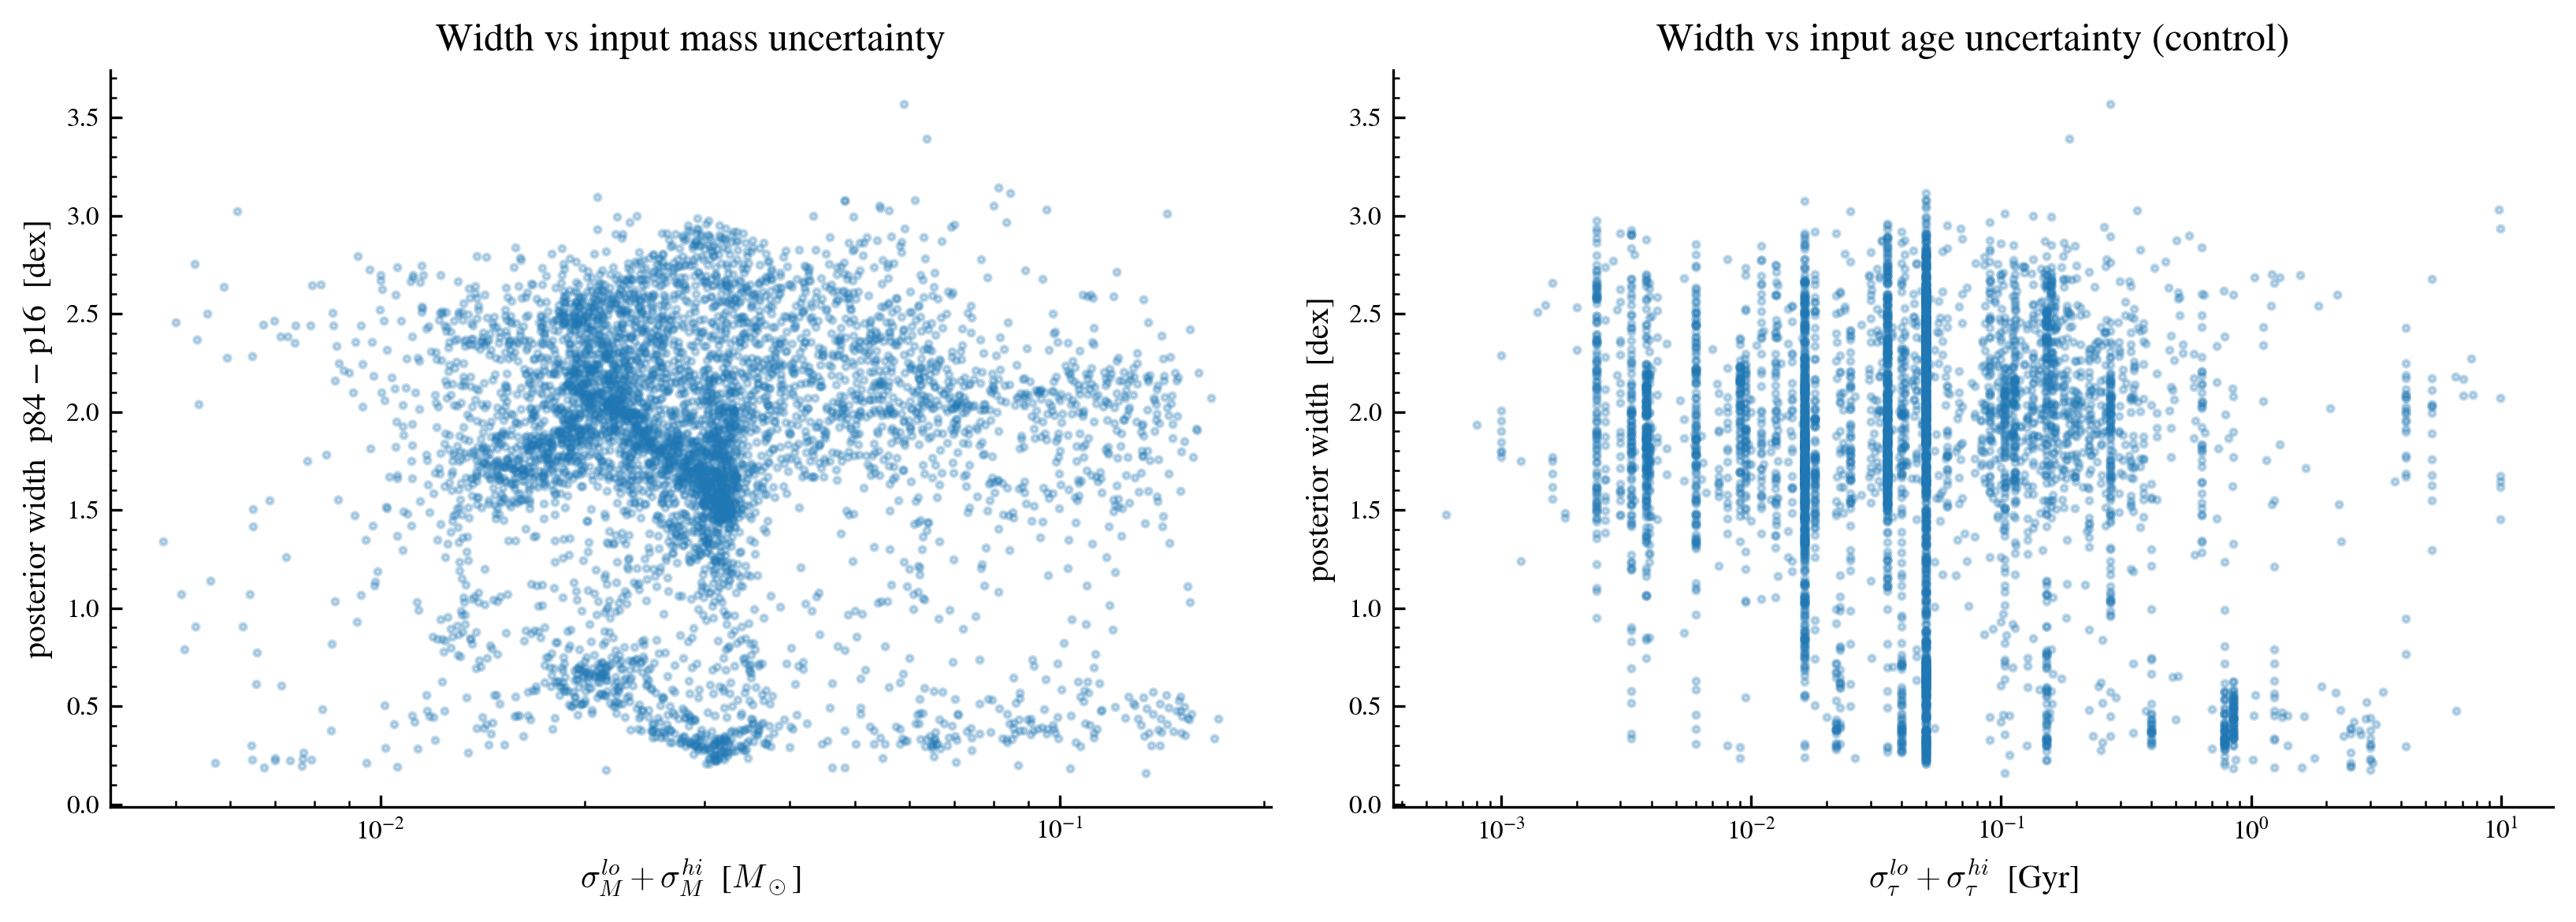

Spearman ρ(mass σ, width) = -0.024   (p = 7.63e-02)
Spearman ρ(age σ,  width) = -0.030   (p = 2.76e-02)


In [11]:
v = val_results[['p16', 'p84', 'mass_msun_err_lo', 'mass_msun_err_hi']].notna().all(axis=1)
rv = val_results[v]
mass_err = (rv['mass_msun_err_lo'] + rv['mass_msun_err_hi']).values
width    = (rv['p84'] - rv['p16']).values
age_err  = (rv['age_err_lo_gyr'].fillna(0) + rv['age_err_hi_gyr'].fillna(0)).values

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(mass_err, width, s=4, alpha=0.25)
axes[0].set_xscale('log')
axes[0].set_xlabel(r'$\sigma_M^{lo} + \sigma_M^{hi}$  [$M_\odot$]')
axes[0].set_ylabel('posterior width  p84 − p16  [dex]')
axes[0].set_title('Width vs input mass uncertainty')

m_age = age_err > 0
axes[1].scatter(age_err[m_age], width[m_age], s=4, alpha=0.25)
axes[1].set_xscale('log')
axes[1].set_xlabel(r'$\sigma_\tau^{lo} + \sigma_\tau^{hi}$  [Gyr]')
axes[1].set_ylabel('posterior width  [dex]')
axes[1].set_title('Width vs input age uncertainty (control)')
plt.tight_layout(); plt.show()

r1, p1 = spearmanr(mass_err, width)
r2, p2 = spearmanr(age_err[m_age], width[m_age])
print(f'Spearman ρ(mass σ, width) = {r1:+.3f}   (p = {p1:.2e})')
print(f'Spearman ρ(age σ,  width) = {r2:+.3f}   (p = {p2:.2e})')

# Section C — Sample posterior: uncertainty calibration + bimodality

## C.1 Posterior width vs |residual|

If posteriors are honest, wider ones should accompany larger absolute errors.

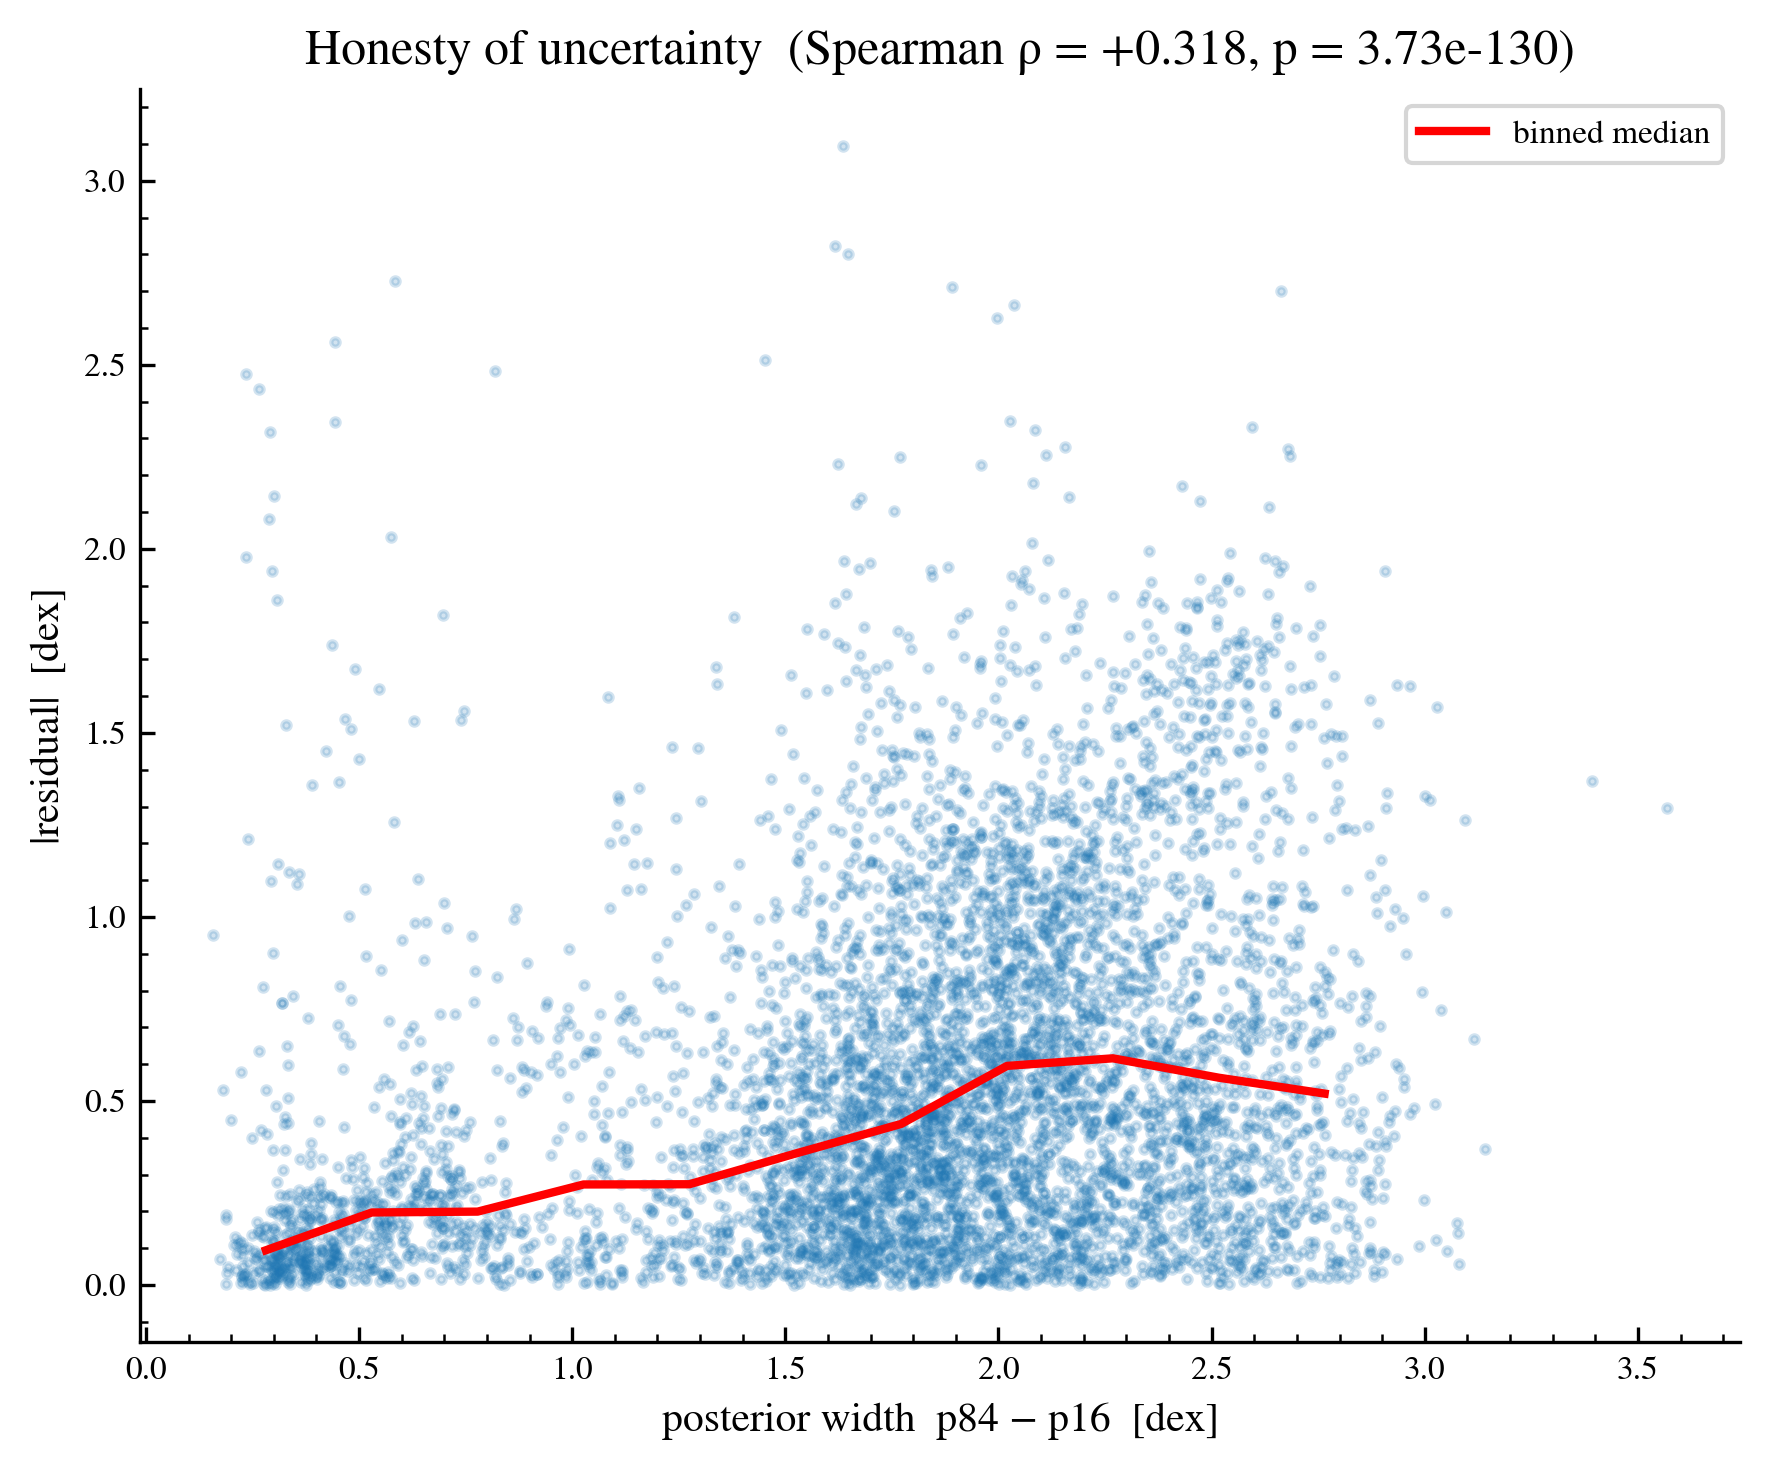

In [13]:
v = val_results[['p16', 'p84', 'residual_dex']].notna().all(axis=1)
width = (val_results.loc[v, 'p84'] - val_results.loc[v, 'p16']).values
absr  = val_results.loc[v, 'residual_dex'].abs().values
rho, pval = spearmanr(width, absr)

bins    = np.linspace(width.min(), np.percentile(width, 99), 12)
centers = 0.5 * (bins[:-1] + bins[1:])
med     = [np.median(absr[(width >= bins[i]) & (width < bins[i+1])]) for i in range(len(bins)-1)]

plt.figure(figsize=(6, 5))
plt.scatter(width, absr, s=4, alpha=0.2)
plt.plot(centers, med, 'r-', lw=2, label='binned median')
plt.xlabel('posterior width  p84 − p16  [dex]')
plt.ylabel('|residual|  [dex]')
plt.title(f'Honesty of uncertainty  (Spearman ρ = {rho:+.3f}, p = {pval:.2e})')
plt.legend(); plt.tight_layout(); plt.show()

## C.2 Bimodal posterior examples

3603 / 5515 (65.3%) k-fold val posteriors are bimodal (≥2 peaks, each ≥30% of max, separated ≥0.4 dex)


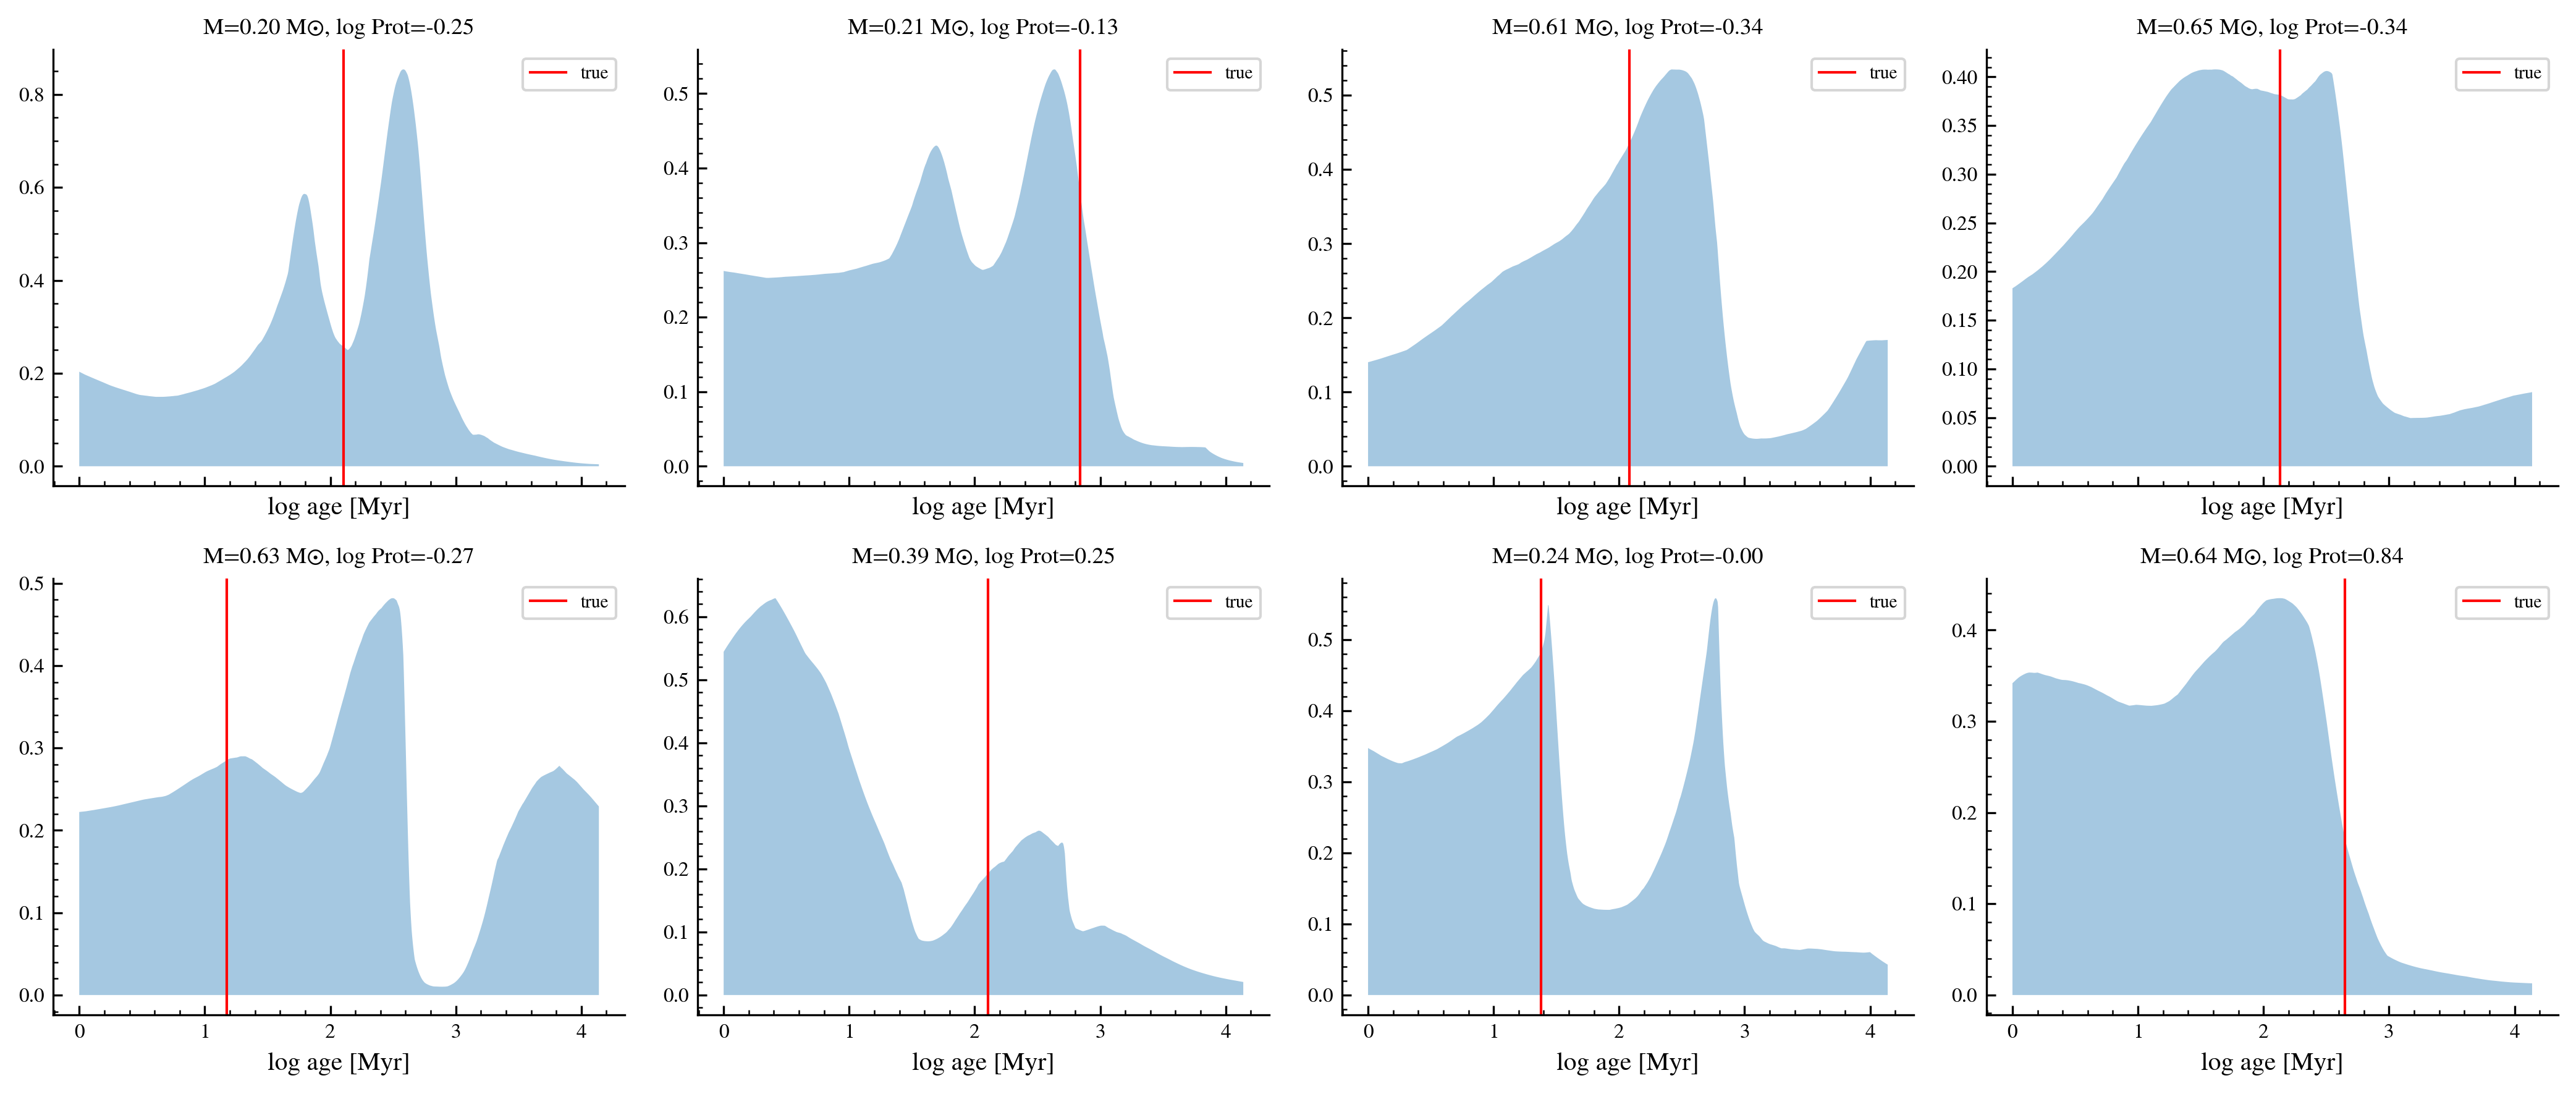

In [14]:
def find_modes(posterior, grid, height_frac=0.3, separation_dex=0.4):
    sep_idx = int(separation_dex / (grid[1] - grid[0]))
    peaks, _ = find_peaks(posterior, height=height_frac * posterior.max(), distance=sep_idx)
    return grid[peaks]

n_modes  = np.array([len(find_modes(p, LOGA_GRID)) for p in val_posteriors])
bimodal  = np.where(n_modes >= 2)[0]
print(f'{len(bimodal)} / {len(n_modes)} ({len(bimodal)/len(n_modes)*100:.1f}%) k-fold val posteriors are bimodal '
      f'(≥2 peaks, each ≥30% of max, separated ≥0.4 dex)')

np.random.seed(7)
sample = np.random.choice(bimodal, size=min(8, len(bimodal)), replace=False) if len(bimodal) else []

if len(sample):
    fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True)
    for ax, i in zip(axes.flat, sample):
        ax.fill_between(LOGA_GRID, val_posteriors[i], alpha=0.4)
        ax.axvline(val_results.iloc[i]['log_age_myr'], color='r', lw=1, label='true')
        m  = val_results.iloc[i]['mass_msun']
        pr = val_results.iloc[i]['log_prot']
        ax.set_xlabel('log age [Myr]')
        ax.set_title(f'M={m:.2f} M☉, log Prot={pr:.2f}', fontsize=9)
        ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()
else:
    print('No bimodal posteriors found at current thresholds.')

# Section D — Binarity

## D.1 Residual + width split by RUWE (1.2 threshold)

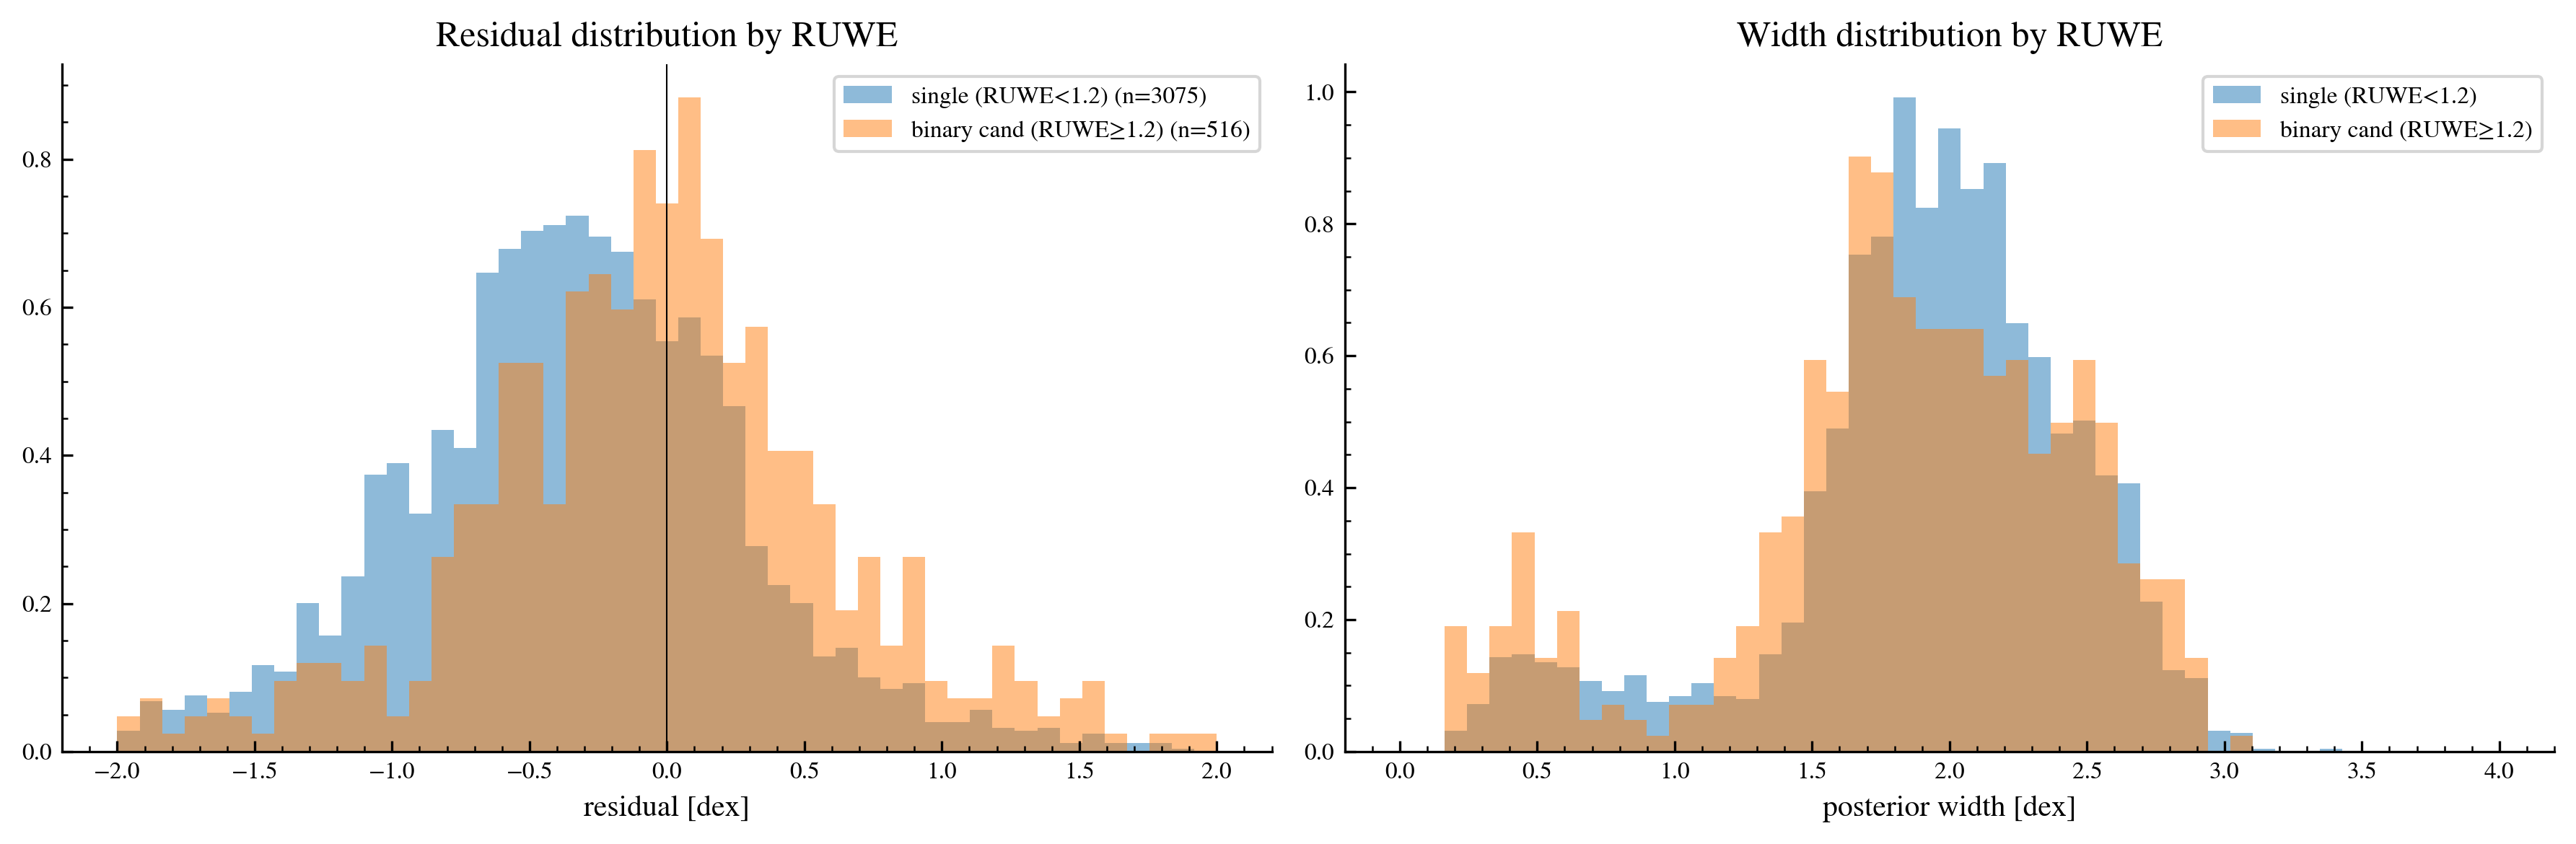

,single (RUWE<1.2),binary cand (RUWE≥1.2)
n,3075.0000,516.0000
median_residual,-0.3386,-0.0339
med_|residual|,0.4601,0.3716
med_width,1.9782,1.8720
coverage_68,0.8416,0.8585


In [15]:
mask = val_results['ruwe'].notna()
sub  = val_results[mask].copy()
sub['is_binary_cand'] = sub['ruwe'] >= 1.2
groups = {'single (RUWE<1.2)'      : sub[~sub['is_binary_cand']],
          'binary cand (RUWE≥1.2)' : sub[ sub['is_binary_cand']]}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins_r = np.linspace(-2, 2, 50)
bins_w = np.linspace(0, 4, 50)
for label, g in groups.items():
    axes[0].hist(g['residual_dex'].dropna(), bins=bins_r, density=True,
                 alpha=0.5, label=f'{label} (n={len(g)})')
    axes[1].hist((g['p84'] - g['p16']).dropna(), bins=bins_w, density=True,
                 alpha=0.5, label=label)
axes[0].axvline(0, color='k', lw=0.5)
axes[0].set_xlabel('residual [dex]'); axes[0].set_title('Residual distribution by RUWE'); axes[0].legend()
axes[1].set_xlabel('posterior width [dex]'); axes[1].set_title('Width distribution by RUWE'); axes[1].legend()
plt.tight_layout(); plt.show()

binarity_table = pd.DataFrame({
    label: {
        'n'                : len(g),
        'median_residual'  : float(g['residual_dex'].median()),
        'med_|residual|'   : float(g['residual_dex'].abs().median()),
        'med_width'        : float((g['p84'] - g['p16']).median()),
        'coverage_68'      : float(((g['log_age_myr'] >= g['p16']) &
                                    (g['log_age_myr'] <= g['p84'])).mean()),
    } for label, g in groups.items()
}).round(4)
binarity_table

## D.2 Jao gap zoom (0.25–0.6 M☉)

Rolling median of residual and posterior width across the fully convective boundary at ~0.35 M☉.

N stars in 0.25–0.60 M☉ window: 3788


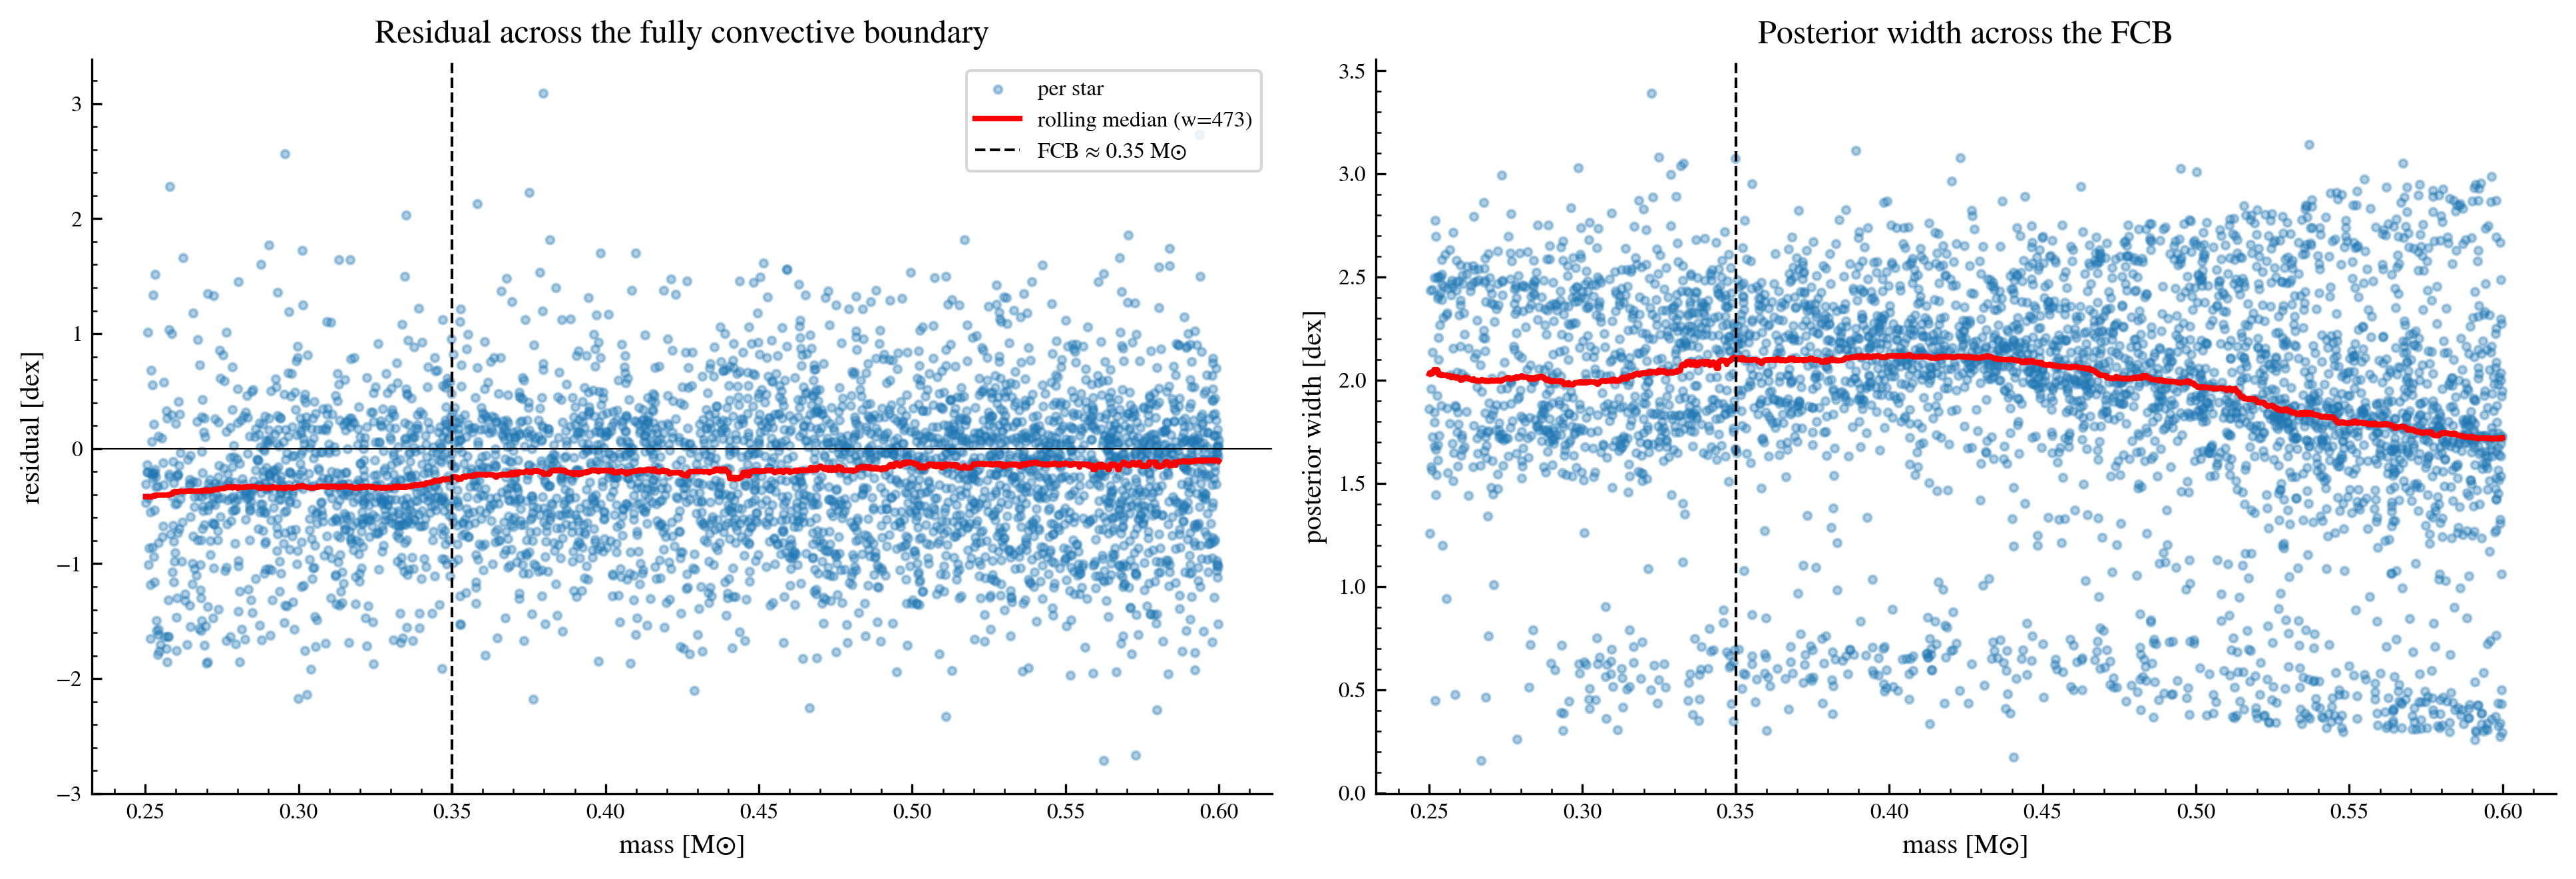

In [16]:
jao = (val_results[(val_results['mass_msun'] >= 0.25) & (val_results['mass_msun'] <= 0.60)]
       .dropna(subset=['residual_dex', 'p16', 'p84'])
       .sort_values('mass_msun')
       .reset_index(drop=True))
n_jao = len(jao)
print(f'N stars in 0.25–0.60 M☉ window: {n_jao}')

if n_jao >= 20:
    win = max(15, n_jao // 8)
    jao['width']         = jao['p84'] - jao['p16']
    jao['rolling_resid'] = jao['residual_dex'].rolling(win, center=True, min_periods=5).median()
    jao['rolling_width'] = jao['width'].rolling(win, center=True, min_periods=5).median()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].scatter(jao['mass_msun'], jao['residual_dex'], s=8, alpha=0.35, label='per star')
    axes[0].plot(jao['mass_msun'], jao['rolling_resid'], 'r-', lw=2, label=f'rolling median (w={win})')
    axes[0].axhline(0, color='k', lw=0.5)
    axes[0].axvline(0.35, color='k', lw=1, ls='--', label='FCB ≈ 0.35 M☉')
    axes[0].set_xlabel('mass [M☉]'); axes[0].set_ylabel('residual [dex]')
    axes[0].set_title('Residual across the fully convective boundary'); axes[0].legend(fontsize=8)

    axes[1].scatter(jao['mass_msun'], jao['width'], s=8, alpha=0.35)
    axes[1].plot(jao['mass_msun'], jao['rolling_width'], 'r-', lw=2)
    axes[1].axvline(0.35, color='k', lw=1, ls='--')
    axes[1].set_xlabel('mass [M☉]'); axes[1].set_ylabel('posterior width [dex]')
    axes[1].set_title('Posterior width across the FCB')
    plt.tight_layout(); plt.show()
else:
    print('Too few low-mass stars in the val set for a meaningful FCB plot.')

## D.3 Precision / accuracy split by RUWE

single (RUWE<1.2):       n = 3075
binary cand (RUWE≥1.2):  n = 516

Precision — single


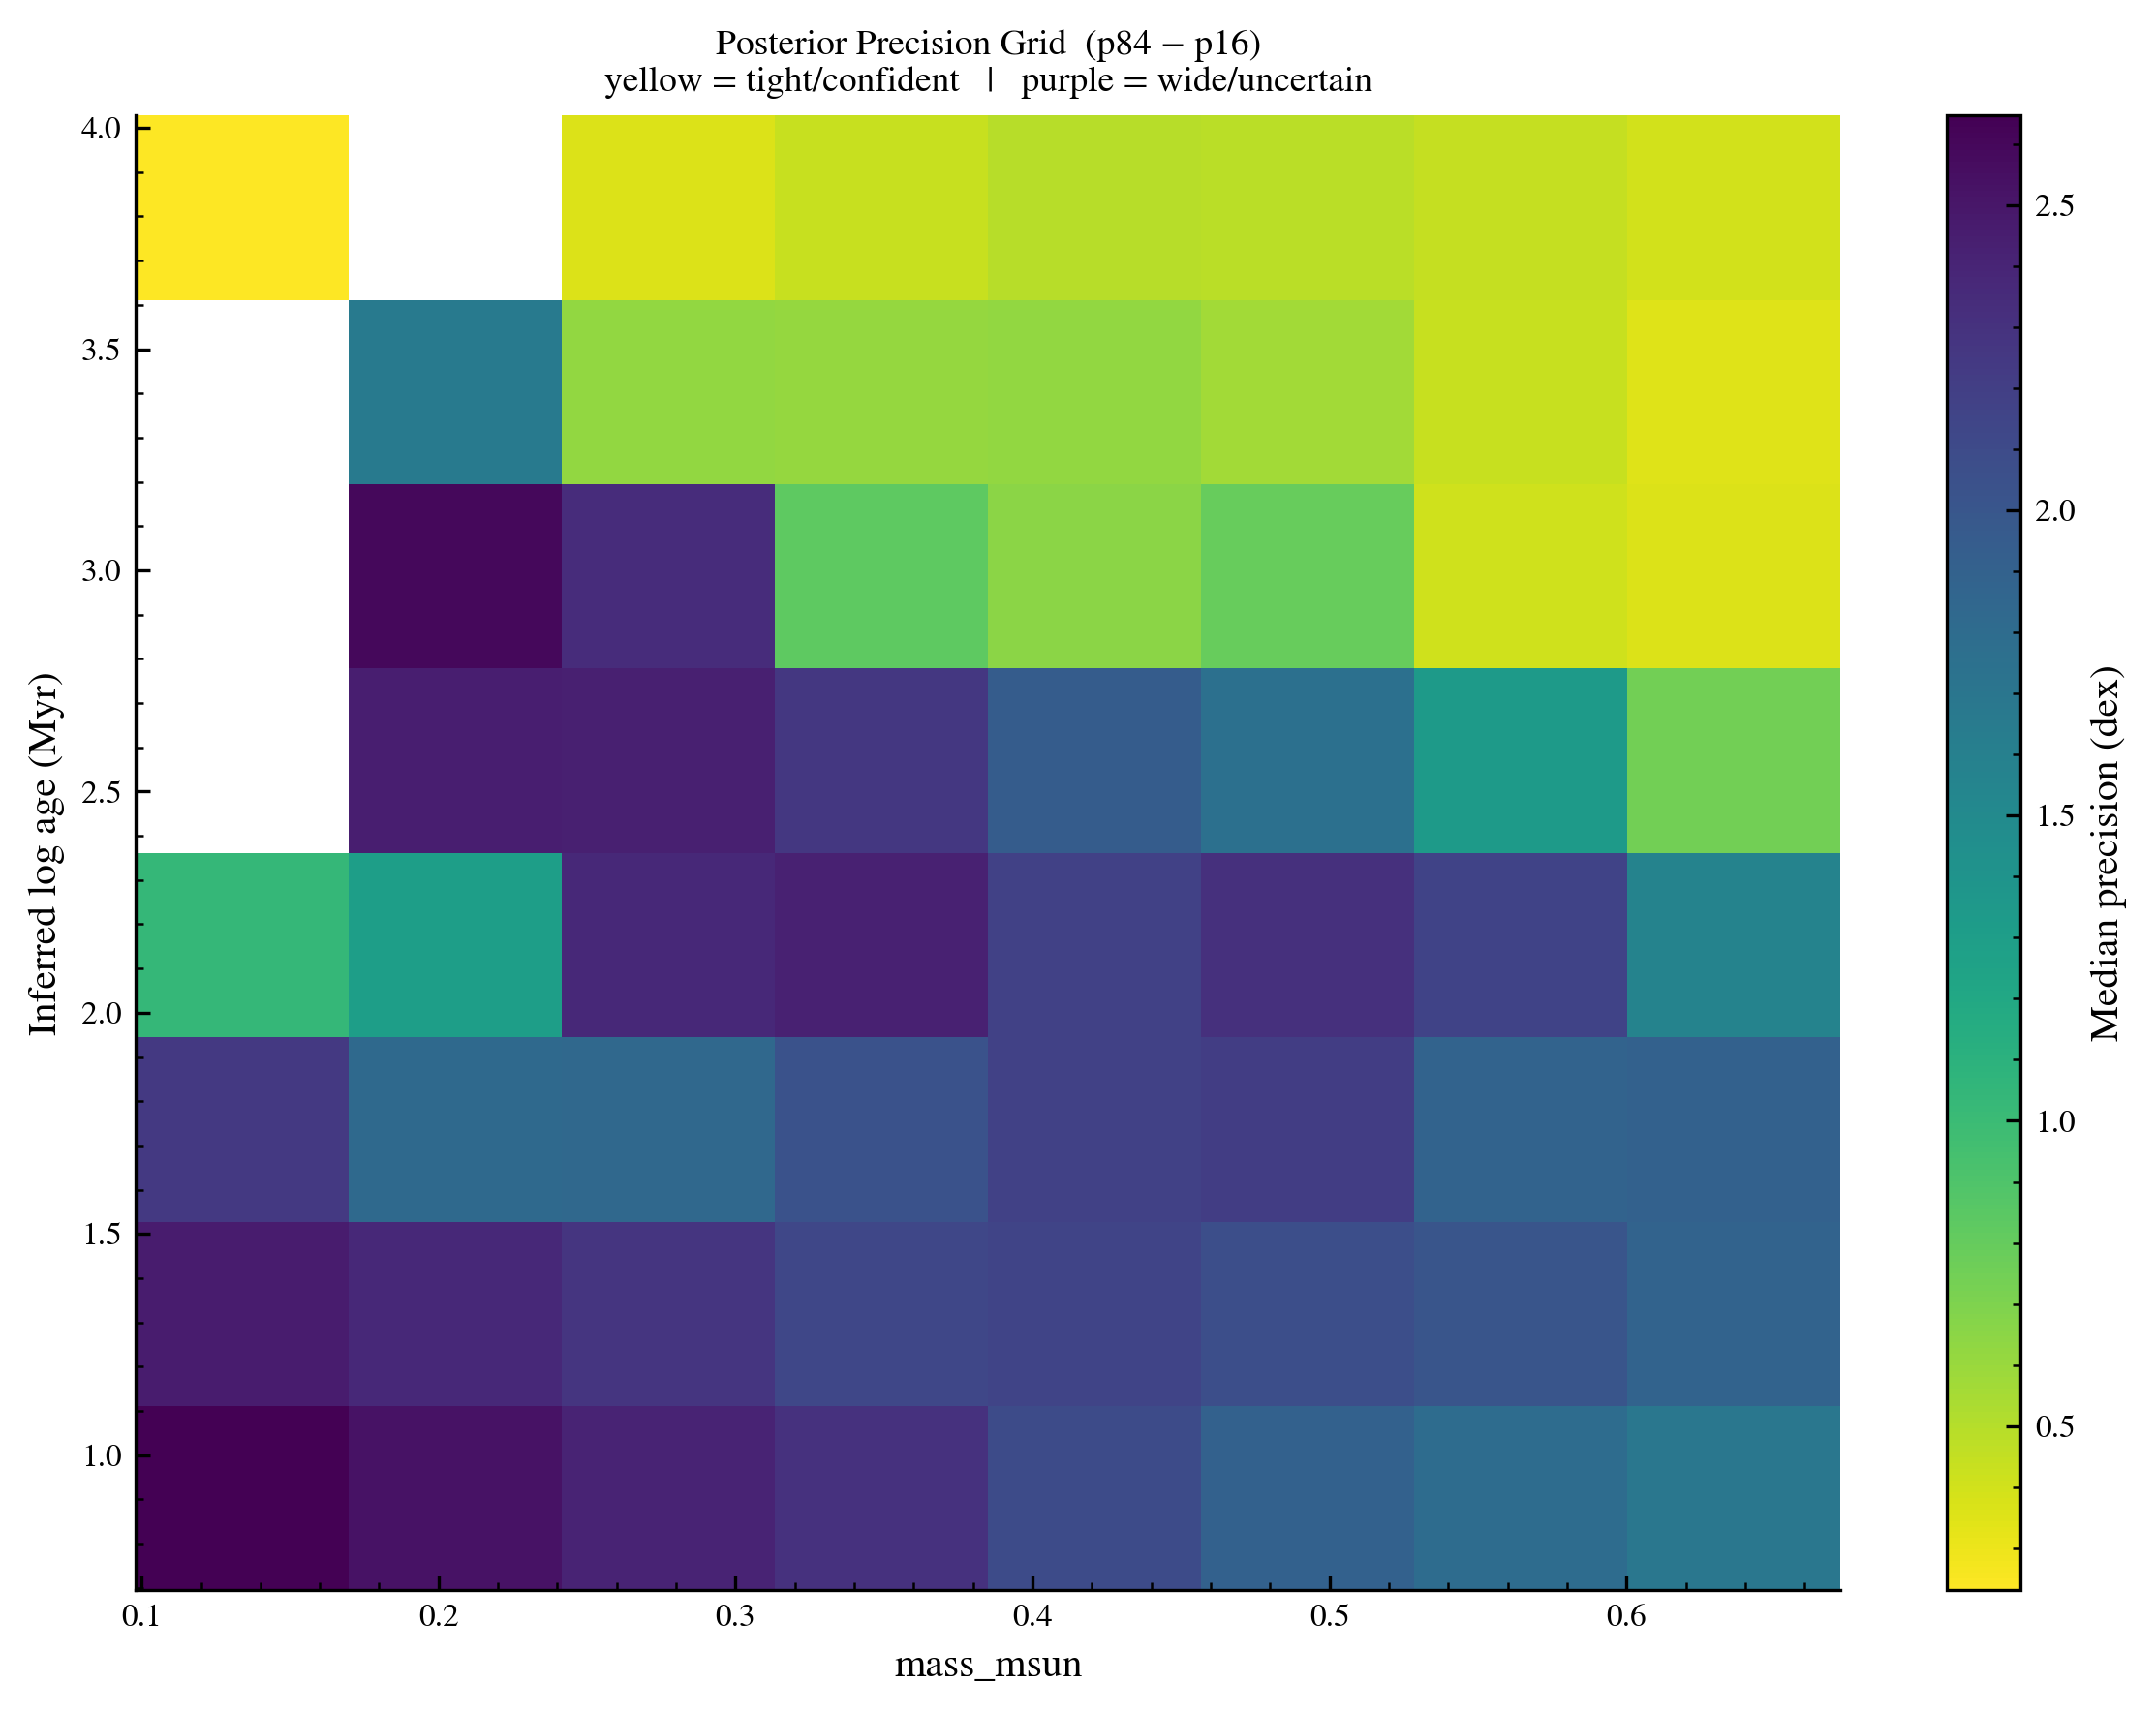


Precision — binary cand


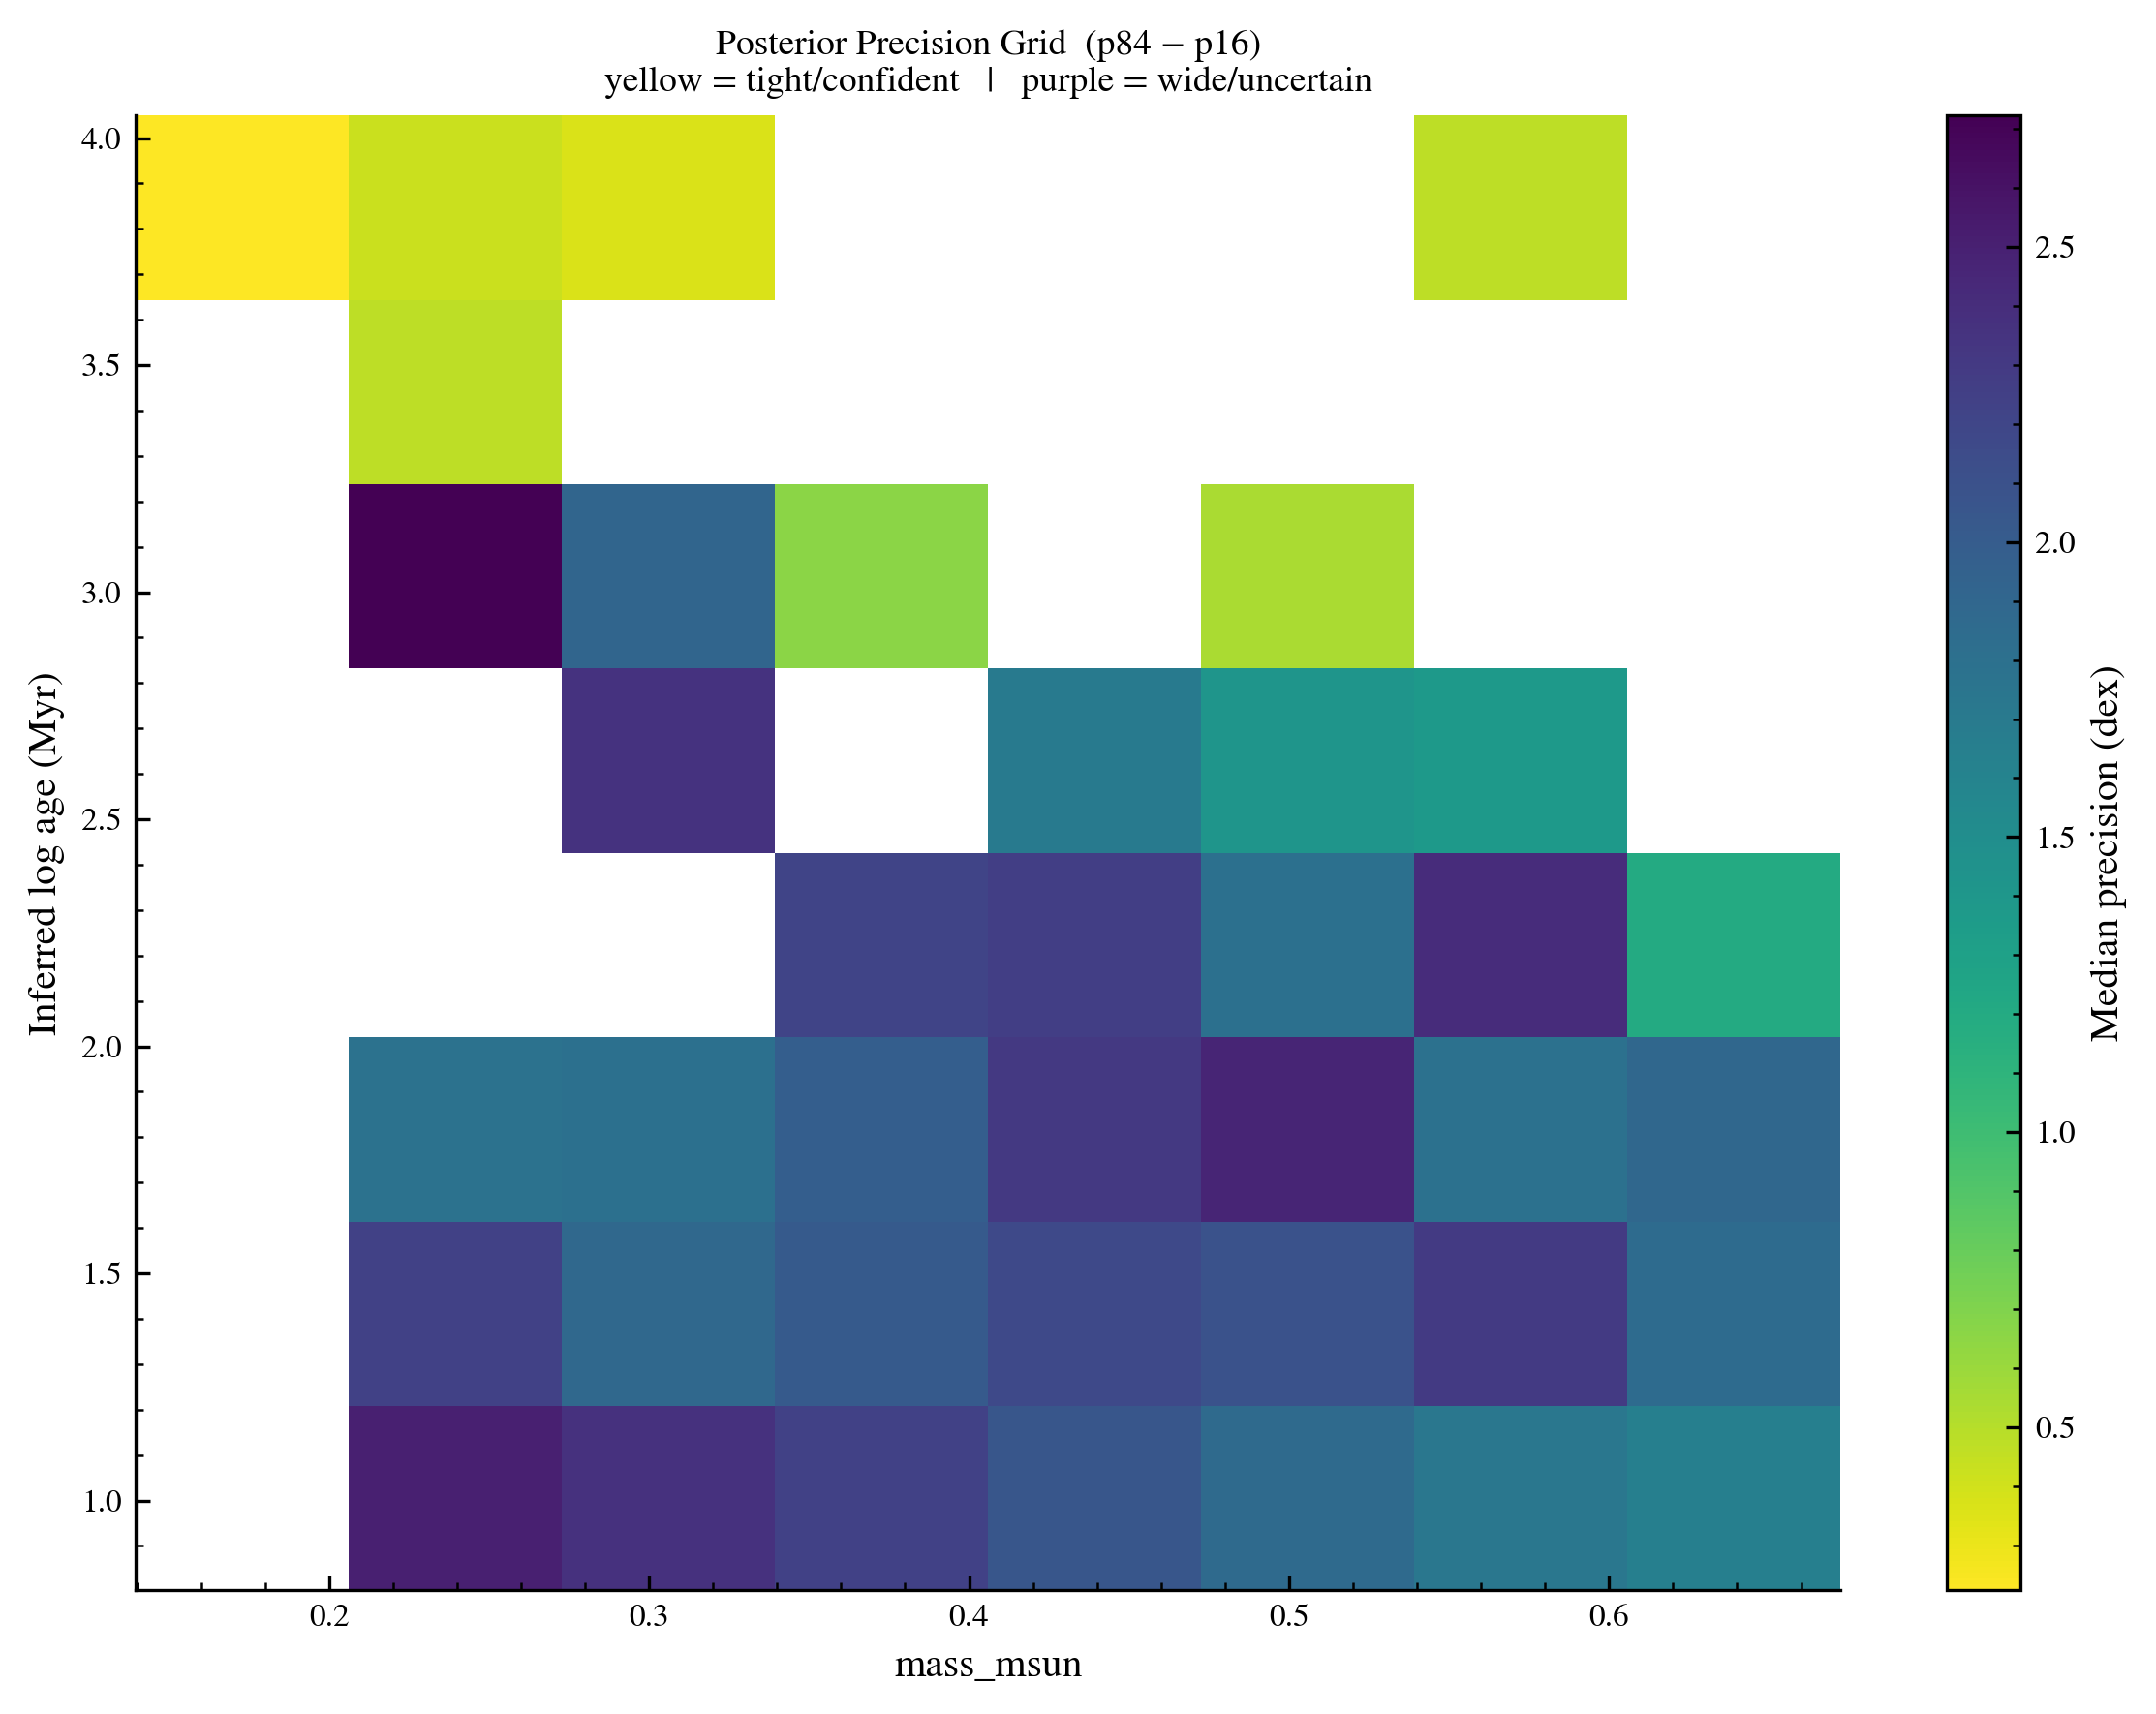


Accuracy — single


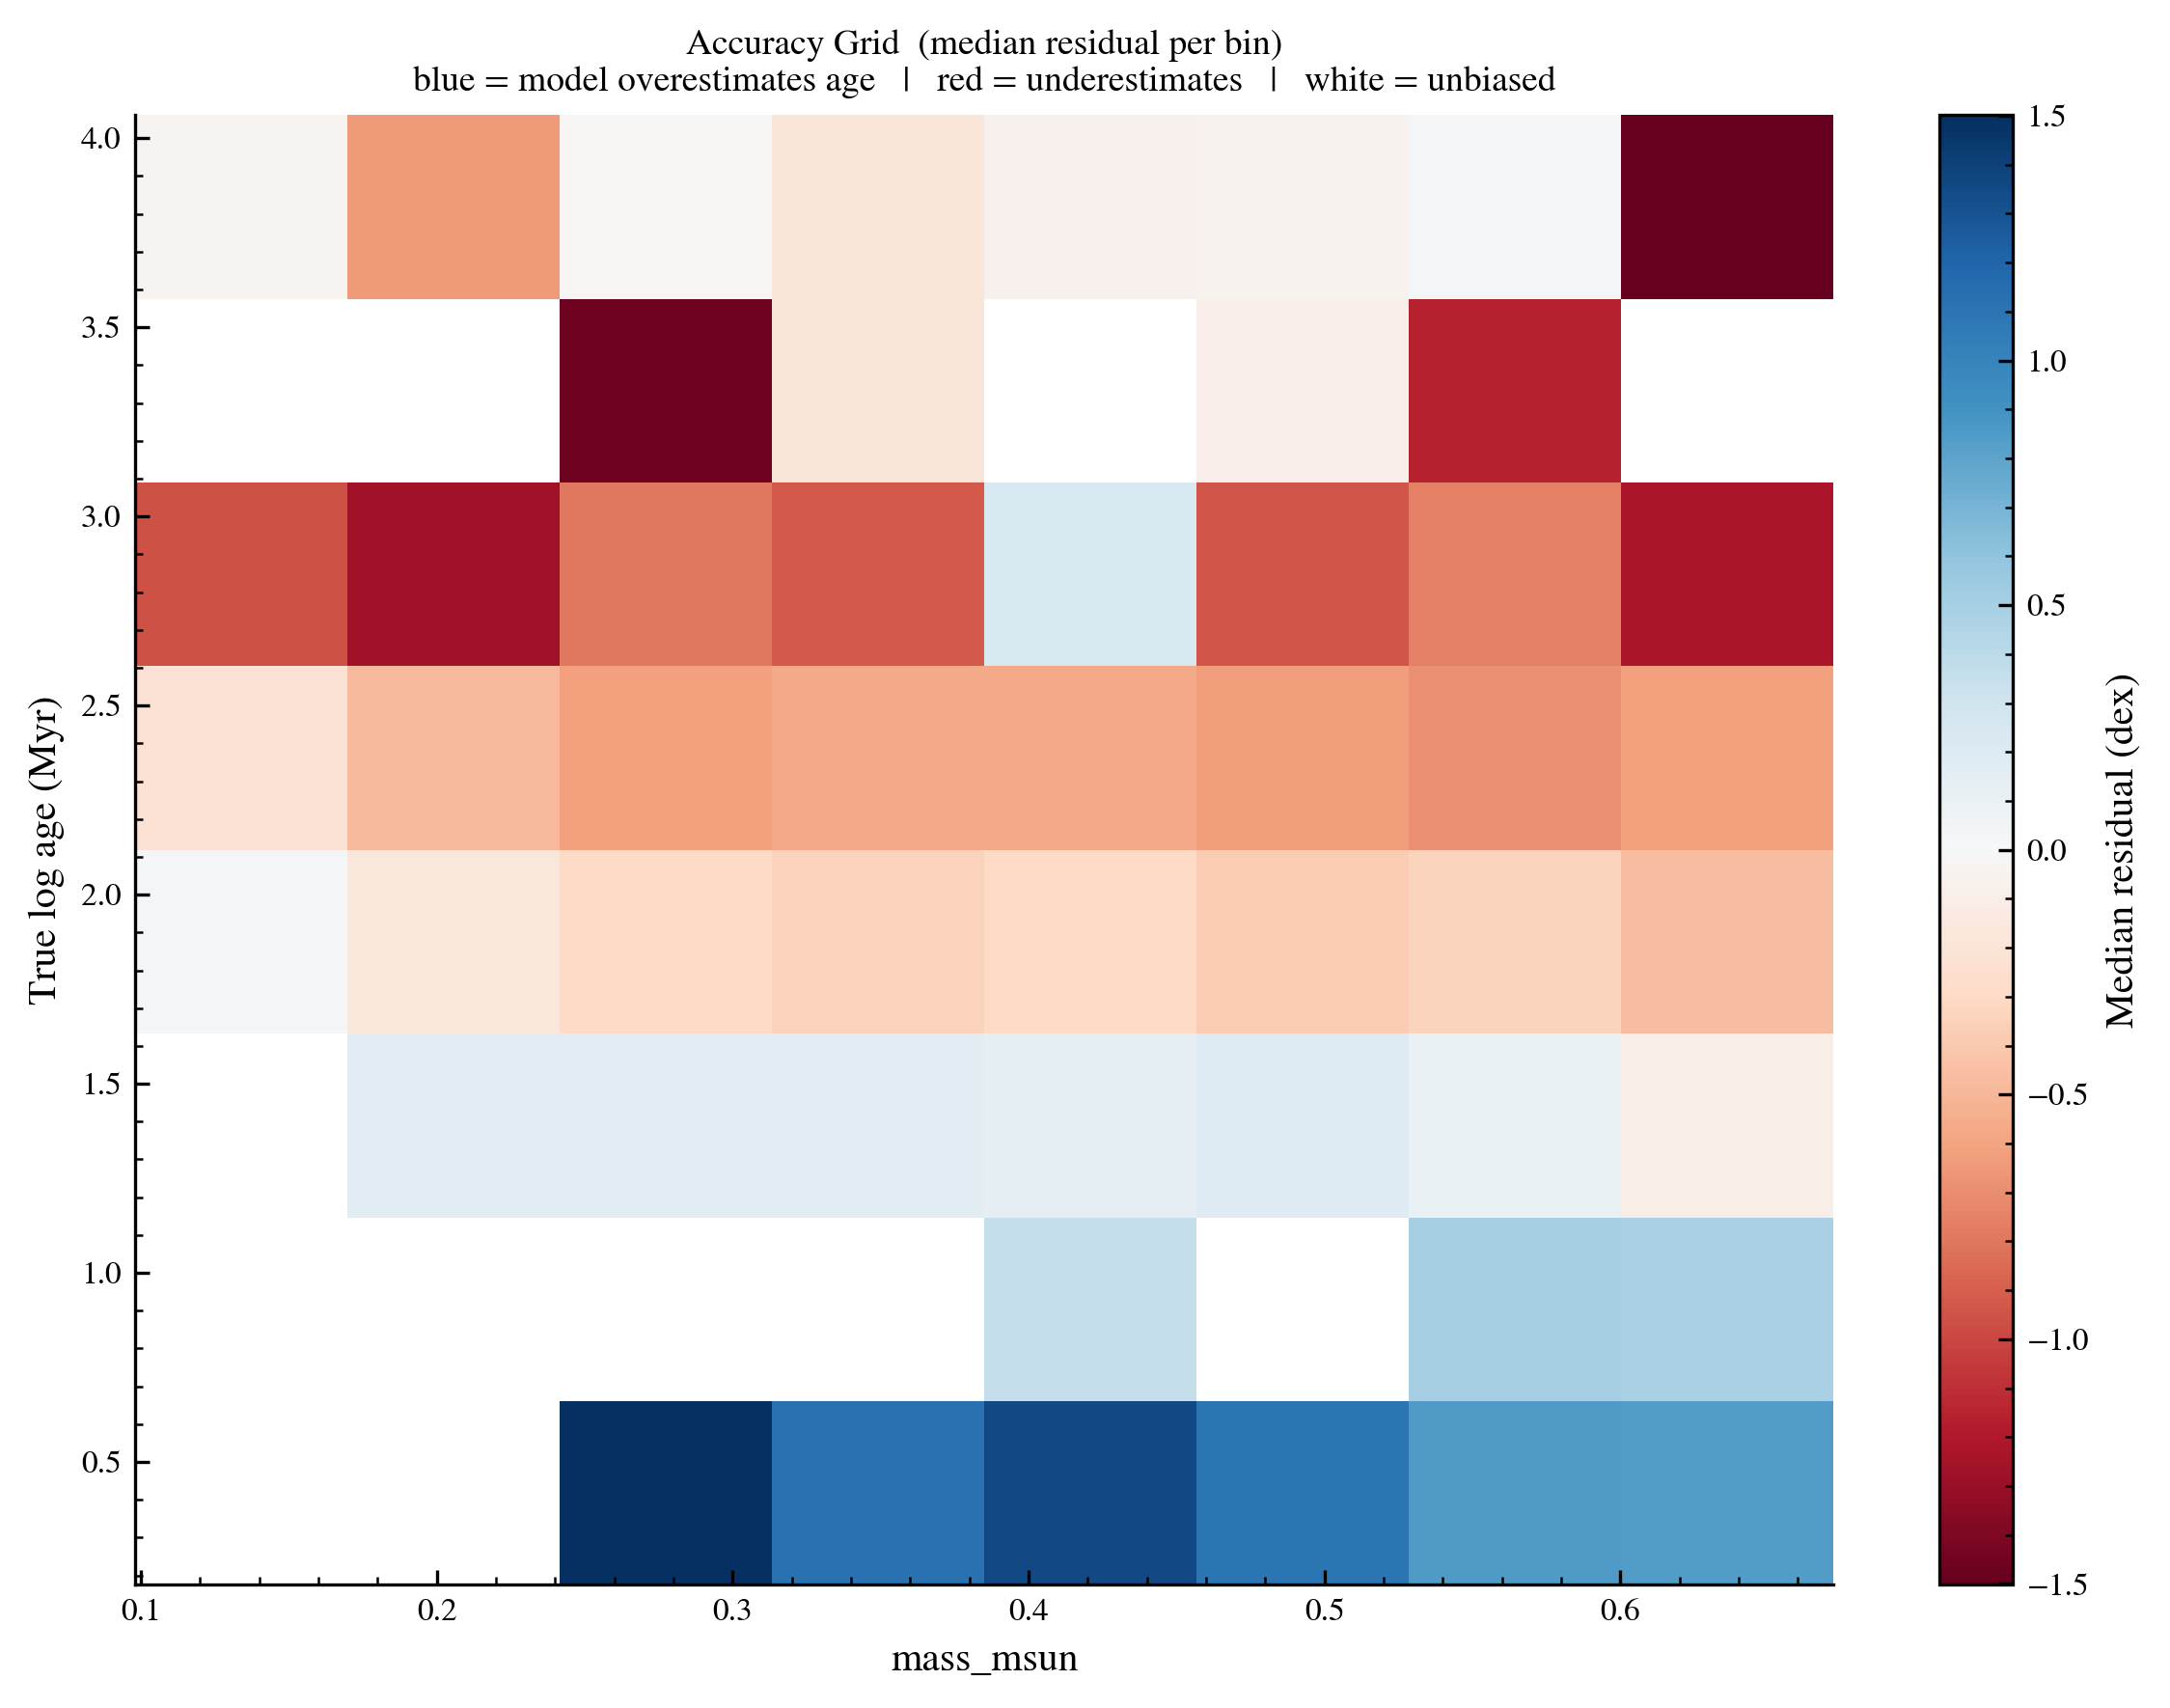


Accuracy — binary cand


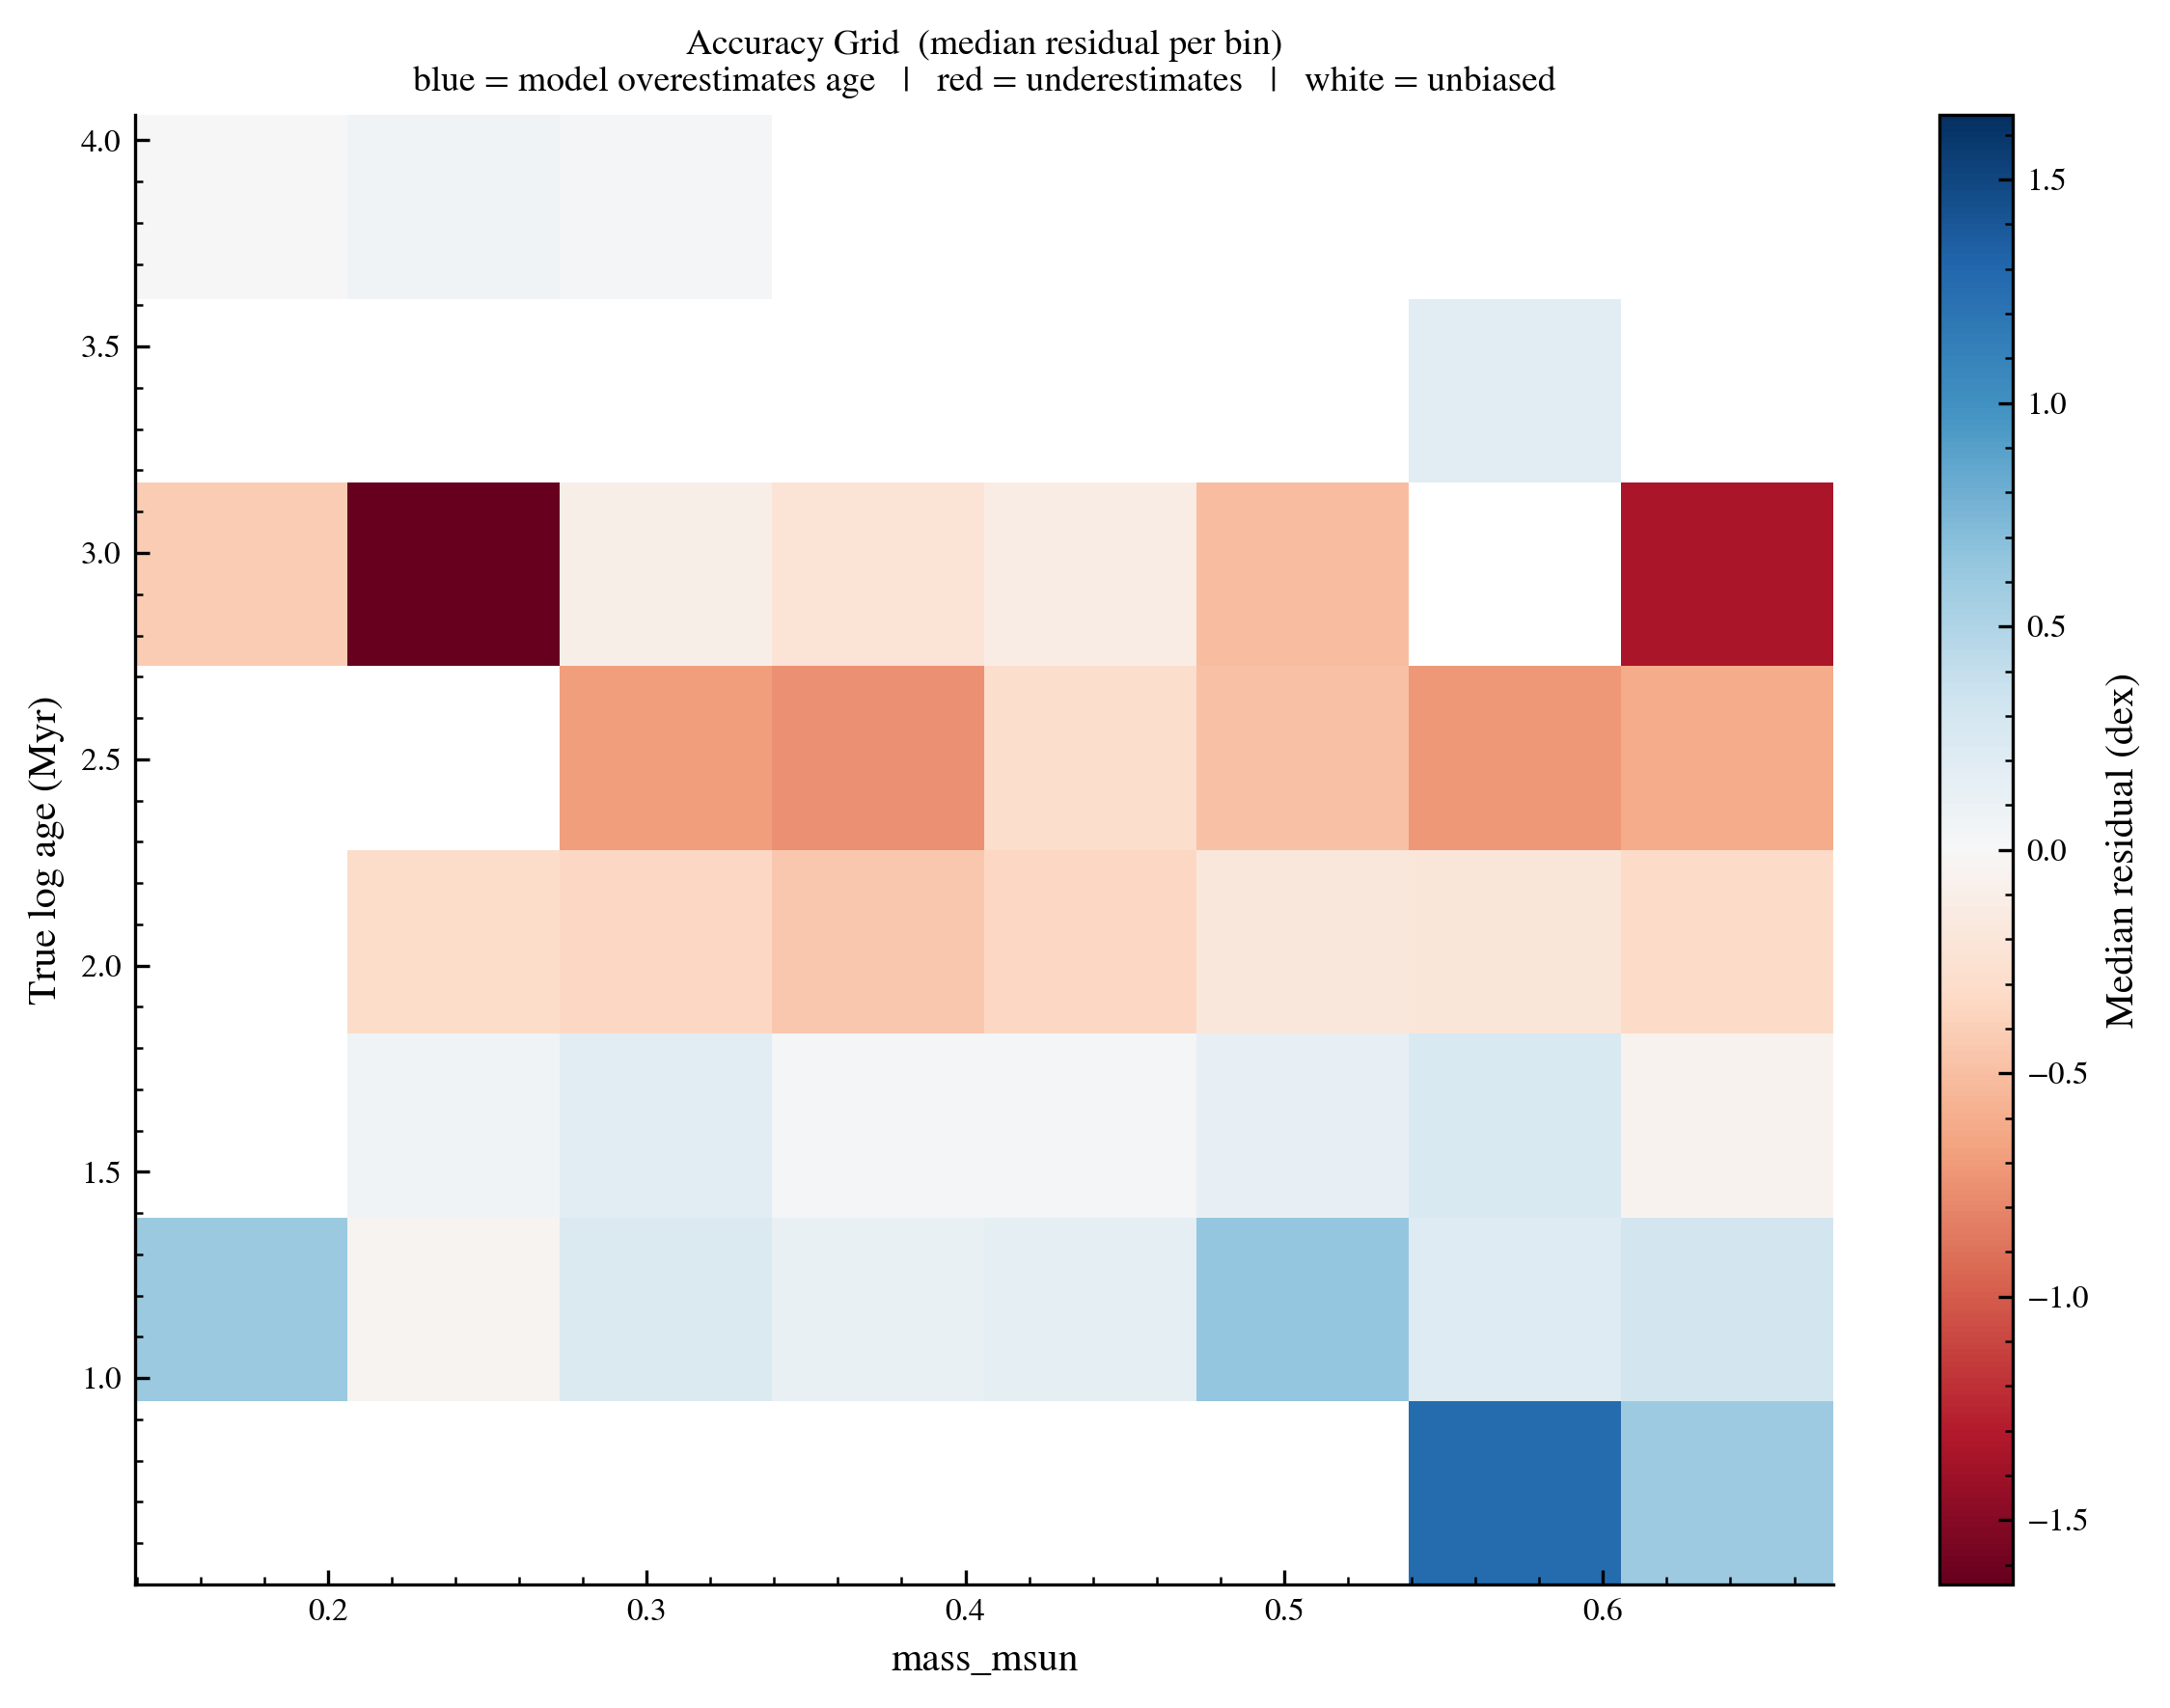

In [17]:
single = val_results[(val_results['ruwe'].notna()) & (val_results['ruwe'] < 1.2)]
binary = val_results[(val_results['ruwe'].notna()) & (val_results['ruwe'] >= 1.2)]
print(f'single (RUWE<1.2):       n = {len(single)}')
print(f'binary cand (RUWE≥1.2):  n = {len(binary)}')

print('\nPrecision — single')
plot_precision_grid(single, x_col='mass_msun')
print('\nPrecision — binary cand')
plot_precision_grid(binary, x_col='mass_msun')
print('\nAccuracy — single')
plot_accuracy_grid(single, x_col='mass_msun')
print('\nAccuracy — binary cand')
plot_accuracy_grid(binary, x_col='mass_msun')

# Section E — Discussion: predicted vs observed fast-rotator fraction per cluster

For each training cluster, average the model's predicted $p(\log P_{\rm rot}\mid \tau_{\rm cluster}, M_\star)$ over the cluster's mass distribution. If the result is bimodal, find the local min between the fast and slow peaks and integrate the left side. Compare to the observed fraction of cluster stars below the same split.

In [18]:
def cluster_prot_pdf(flow, scaler, cluster_df, log_prot_grid):
    log_age = float(cluster_df['log_age_myr'].median())
    masses  = cluster_df['mass_msun'].values
    err_lo  = cluster_df['mass_msun_err_lo'].fillna(float(train_val_df['mass_msun_err_lo'].median())).values
    err_hi  = cluster_df['mass_msun_err_hi'].fillna(float(train_val_df['mass_msun_err_hi'].median())).values

    n_g = len(log_prot_grid)
    pdf = np.zeros(n_g)
    for m, e_lo, e_hi in zip(masses, err_lo, err_hi):
        c = np.zeros((n_g, len(COND_COLS)), dtype=np.float32)
        c[:, 0] = log_age; c[:, 1] = m; c[:, 2] = e_lo; c[:, 3] = e_hi
        c_norm = scaler.transform(c).astype(np.float32)
        x = torch.tensor(log_prot_grid.astype(np.float32)).unsqueeze(1)
        with torch.no_grad():
            lp = flow(torch.tensor(c_norm)).log_prob(x).numpy()
        p = np.exp(lp - lp.max())
        p /= np.trapz(p, log_prot_grid)
        pdf += p
    pdf /= len(masses)
    pdf /= np.trapz(pdf, log_prot_grid)
    return pdf

def fast_slow_split(pdf, grid, height_frac=0.2, separation_dex=0.3):
    sep_idx = int(separation_dex / (grid[1] - grid[0]))
    peaks, _ = find_peaks(pdf, height=height_frac * pdf.max(), distance=sep_idx)
    if len(peaks) < 2:
        return None, None
    lo, hi = peaks[0], peaks[1]
    split_idx = lo + int(np.argmin(pdf[lo:hi]))
    fast_frac = float(np.trapz(pdf[:split_idx + 1], grid[:split_idx + 1]))
    return float(grid[split_idx]), fast_frac

In [19]:
log_prot_grid = np.linspace(-1.0, 2.0, 400)

cluster_sizes = train_val_df.dropna(subset=['cluster_name']).groupby('cluster_name').size()
cluster_names = cluster_sizes[cluster_sizes >= 15].index.tolist()
print(f'{len(cluster_names)} clusters with ≥15 members in train/val pool')

rows = []
for cname in cluster_names:
    cdf = train_val_df[train_val_df['cluster_name'] == cname]
    # Average across the 5 fold flows for an ensembled prediction
    pdf_stack = np.stack([cluster_prot_pdf(f, s, cdf, log_prot_grid)
                          for f, s in zip(flows, scalers)])
    pdf = pdf_stack.mean(axis=0)
    pdf /= np.trapz(pdf, log_prot_grid)
    split_logp, fast_pred = fast_slow_split(pdf, log_prot_grid)
    if split_logp is None:
        rows.append({'cluster': cname, 'n': len(cdf),
                     'log_age_myr': float(cdf['log_age_myr'].median()),
                     'split_logP': np.nan, 'pred_fast_frac': np.nan, 'obs_fast_frac': np.nan})
        continue
    obs_fast = float((cdf['log_prot'] <= split_logp).mean())
    rows.append({'cluster': cname, 'n': len(cdf),
                 'log_age_myr': float(cdf['log_age_myr'].median()),
                 'split_logP': split_logp,
                 'pred_fast_frac': fast_pred,
                 'obs_fast_frac' : obs_fast})

fast_df = pd.DataFrame(rows).sort_values('log_age_myr').reset_index(drop=True)
fast_df.round(3)

24 clusters with ≥15 members in train/val pool


,cluster,n,log_age_myr,split_logP,pred_fast_frac,obs_fast_frac
0,ROph_L1688,38,0.568,NaN,NaN,NaN
1,NSco,20,0.778,NaN,NaN,NaN
2,BSco,28,0.895,NaN,NaN,NaN
3,R+18,43,1.006,NaN,NaN,NaN
4,DSco,94,1.006,NaN,NaN,NaN
5,SSco,53,1.011,NaN,NaN,NaN
6,Antares,36,1.102,NaN,NaN,NaN
7,Mamonova2025 (24.0 Myr),97,1.380,0.556,0.828,0.763
8,D+24,19,1.568,0.083,0.357,0.368
9,Mamonova2025 (45.0 Myr),87,1.653,NaN,NaN,NaN


Bimodal model predictions: 10 / 24 clusters


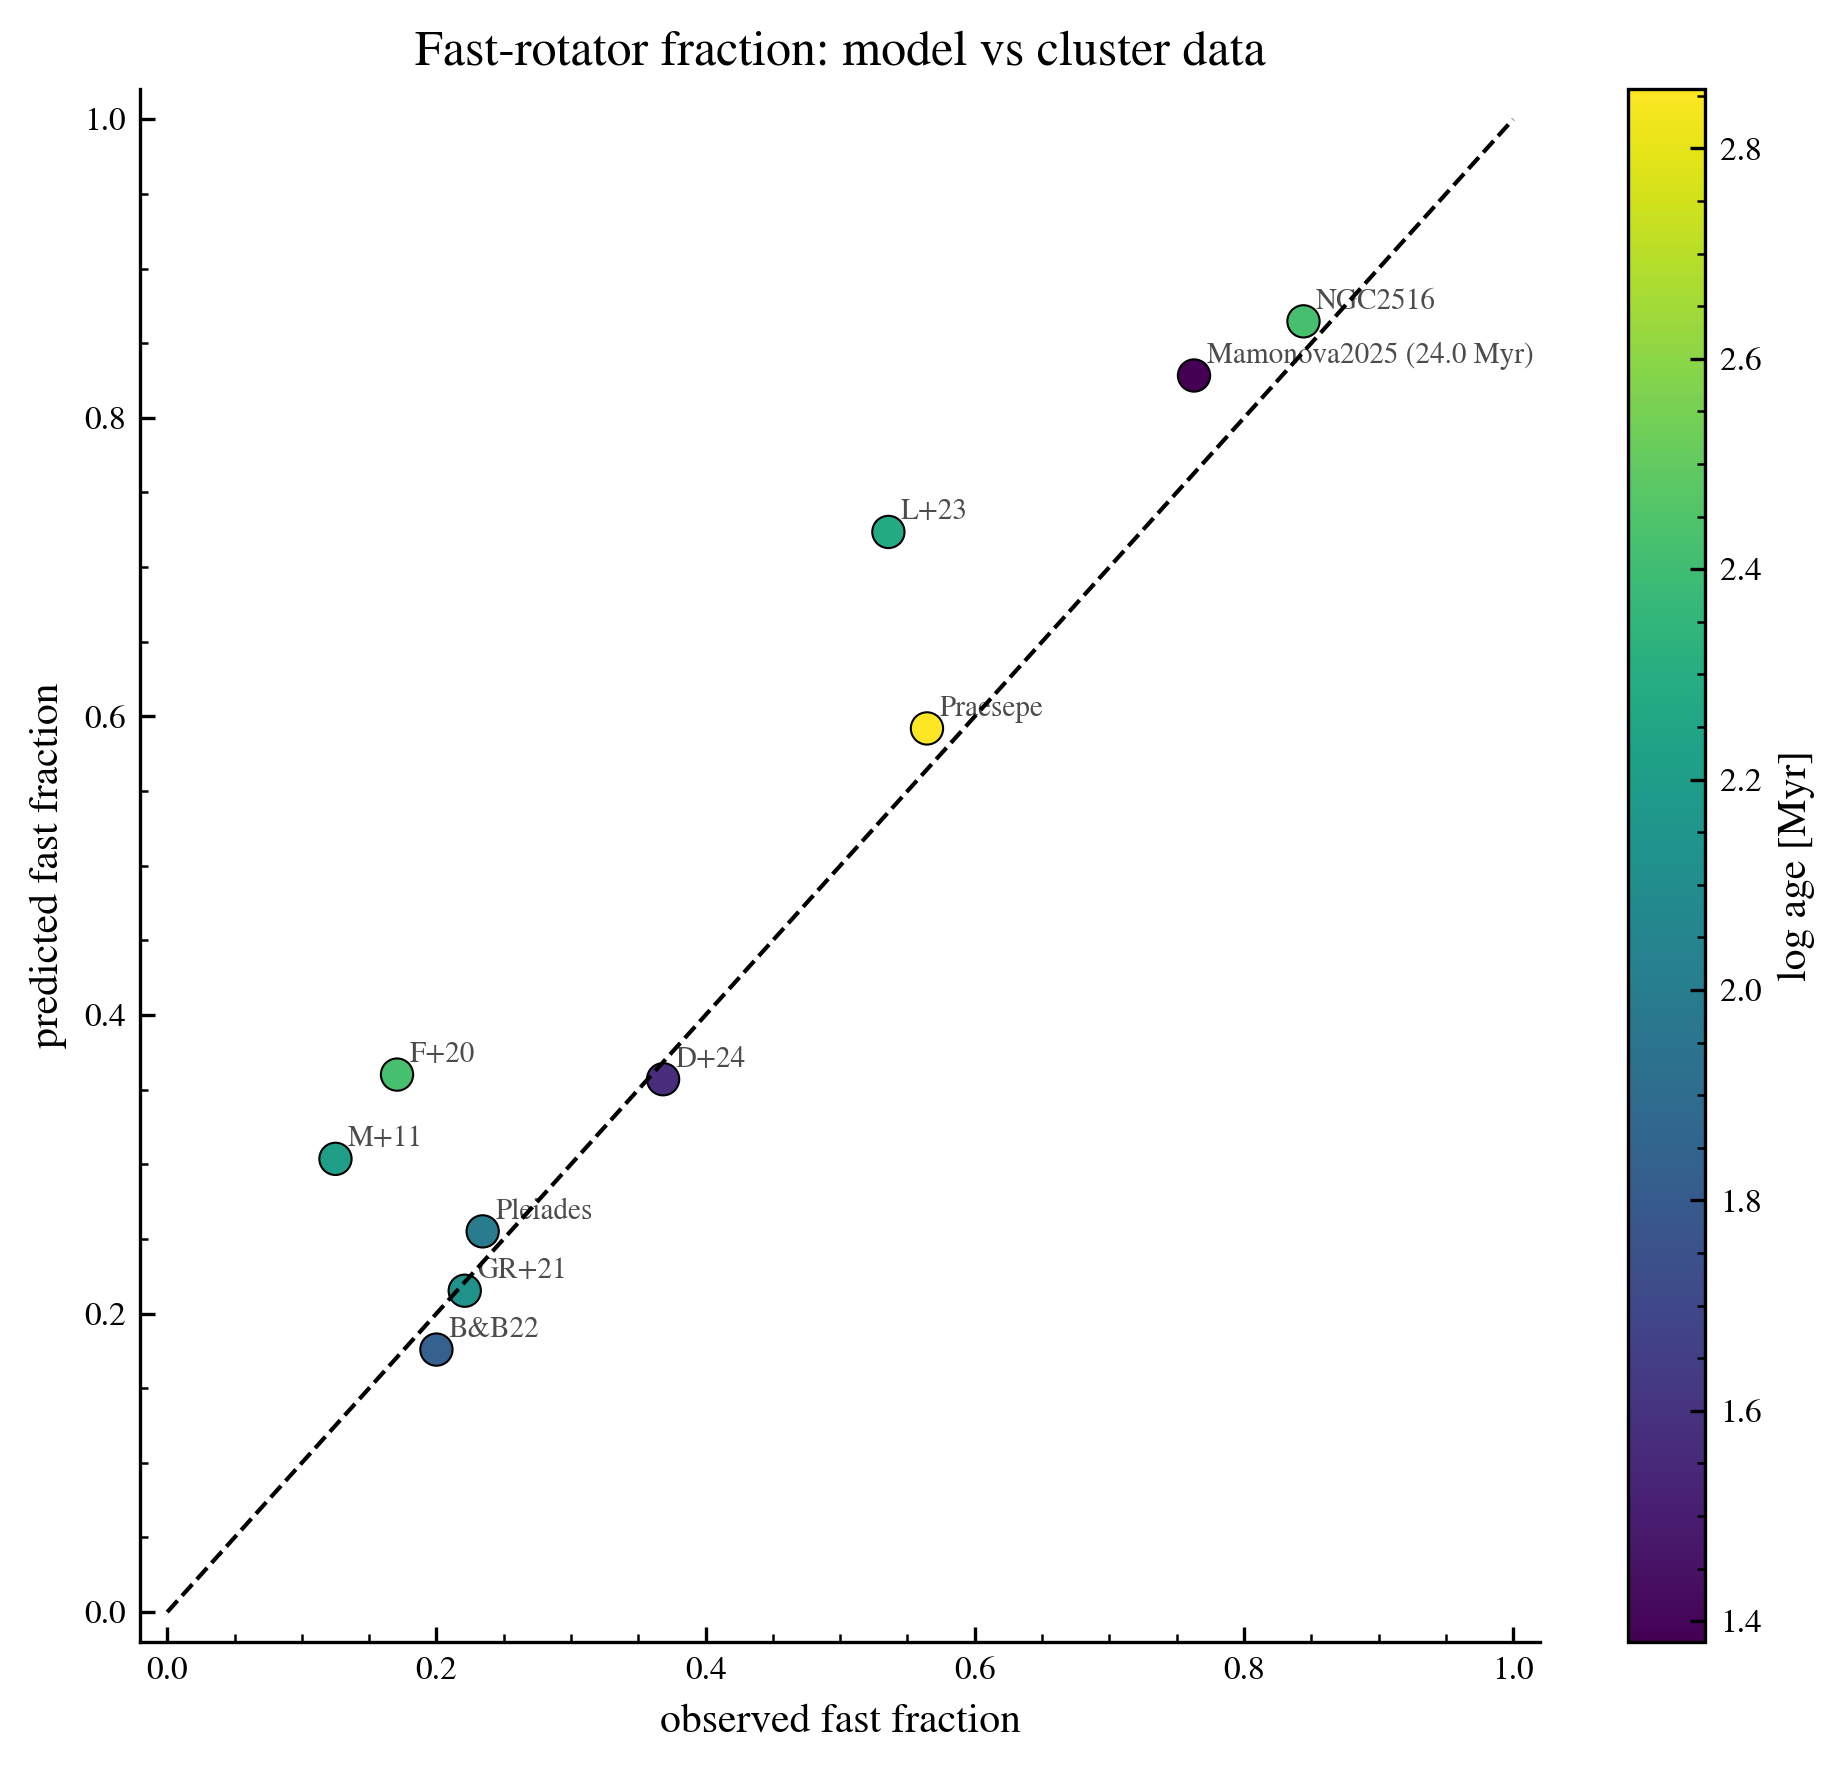

In [20]:
valid = fast_df.dropna(subset=['pred_fast_frac'])
n_bimod = len(valid)
print(f'Bimodal model predictions: {n_bimod} / {len(fast_df)} clusters')

if n_bimod:
    fig, ax = plt.subplots(figsize=(6.5, 6))
    sc = ax.scatter(valid['obs_fast_frac'], valid['pred_fast_frac'],
                    c=valid['log_age_myr'], cmap='viridis',
                    s=60, edgecolors='k', linewidths=0.5)
    plt.colorbar(sc, ax=ax, label='log age [Myr]')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    for _, r in valid.iterrows():
        ax.annotate(r['cluster'], (r['obs_fast_frac'], r['pred_fast_frac']),
                    fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel('observed fast fraction')
    ax.set_ylabel('predicted fast fraction')
    ax.set_title('Fast-rotator fraction: model vs cluster data')
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    plt.tight_layout(); plt.show()
else:
    print('No clusters produced a bimodal model prediction at the current peak thresholds.')

# Section F — M-dwarf rotation "elbow" vs age (Popinchalk et al.)

Popinchalk et al. report that the mass / spectral type at which a coeval population transitions from rapid to slow rotation (the "elbow") moves to later types with age, reaching ~M4 (≈0.22 M☉) by Praesepe age (~700 Myr).

If the flow captured this physics, $p(\log P_{\rm rot}\mid \tau, M)$ at fixed $\tau$ should bend from a slow sequence at higher mass into a fast regime at lower mass, with the bend location shifting to smaller $M$ as $\tau$ grows.

## F.1 Heatmap stack — log Prot vs mass at six fixed ages

The white line is the per-mass mode of $p(\log P_{\rm rot}\mid \tau, M)$ — its bend marks the elbow.

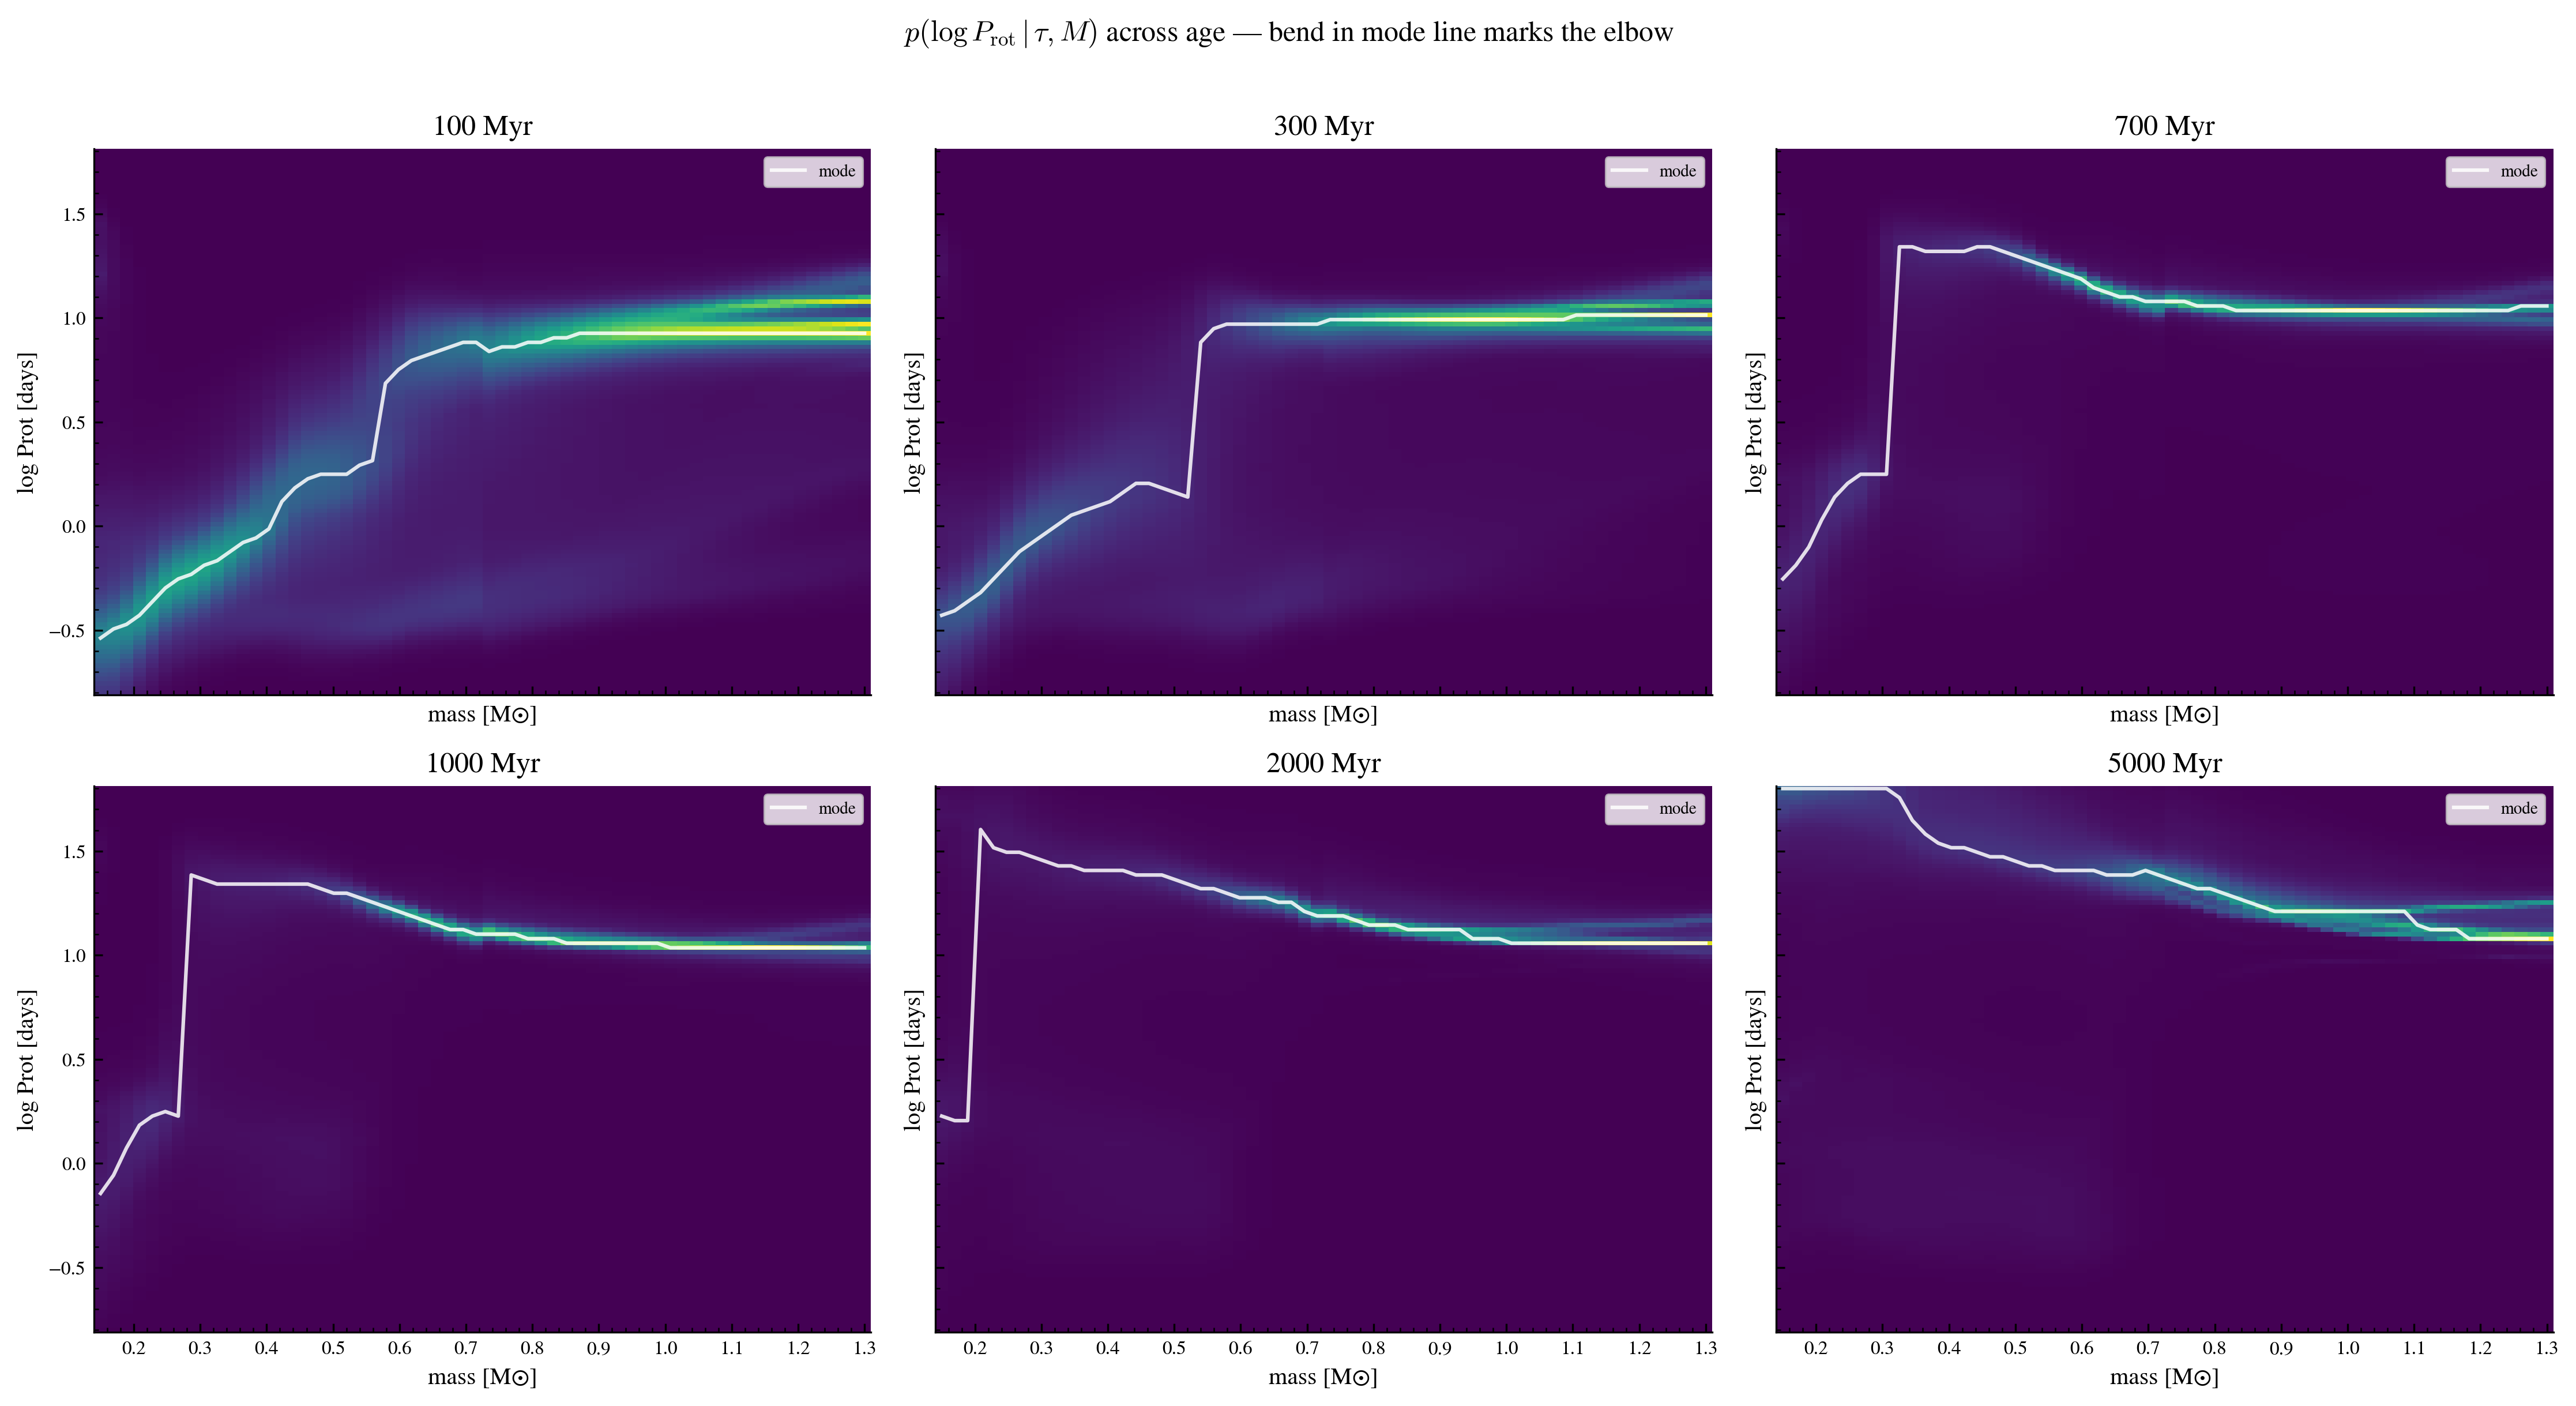

In [28]:
def median_mass_err(mass, mass_tol=0.05):
    near = train_val_df[(train_val_df['mass_msun'] > mass - mass_tol) &
                        (train_val_df['mass_msun'] < mass + mass_tol)]
    if len(near) < 5:
        return (float(train_val_df['mass_msun_err_lo'].median()),
                float(train_val_df['mass_msun_err_hi'].median()))
    return (float(near['mass_msun_err_lo'].median()),
            float(near['mass_msun_err_hi'].median()))

def prot_pdf_at(log_age, mass, log_prot_grid):
    """Ensembled p(log_prot | tau, M) across the 5 fold flows."""
    e_lo, e_hi = median_mass_err(mass)
    n_g = len(log_prot_grid)
    c = np.zeros((n_g, len(COND_COLS)), dtype=np.float32)
    c[:, 0] = log_age; c[:, 1] = mass; c[:, 2] = e_lo; c[:, 3] = e_hi
    x = torch.tensor(log_prot_grid.astype(np.float32)).unsqueeze(1)
    pdfs = []
    for flow, scaler in zip(flows, scalers):
        c_norm = scaler.transform(c).astype(np.float32)
        with torch.no_grad():
            lp = flow(torch.tensor(c_norm)).log_prob(x).numpy()
        p = np.exp(lp - lp.max())
        p /= np.trapz(p, log_prot_grid)
        pdfs.append(p)
    pdf = np.mean(pdfs, axis=0)
    pdf /= np.trapz(pdf, log_prot_grid)
    return pdf

ages_myr      = [100, 300, 700, 1000, 2000, 5000]
mass_grid_h   = np.linspace(0.15, 1.30, 60)
log_prot_grid = np.linspace(-0.8, 1.8, 120)
x_ticks       = np.arange(0.2, 1.35, 0.1)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for ax, age in zip(axes.flat, ages_myr):
    log_age = np.log10(age)
    Z = np.array([prot_pdf_at(log_age, m, log_prot_grid) for m in mass_grid_h])
    ax.pcolormesh(mass_grid_h, log_prot_grid, Z.T, cmap='viridis', shading='auto')
    mode_logp = log_prot_grid[Z.argmax(axis=1)]
    ax.plot(mass_grid_h, mode_logp, 'w-', lw=1.5, alpha=0.85, label='mode')
    ax.set_title(f'{age} Myr')
    ax.set_xlabel('mass [M☉]'); ax.set_ylabel('log Prot [days]')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f'{m:.1f}' for m in x_ticks])
    ax.legend(loc='upper right', fontsize=7)
plt.suptitle(r'$p(\log P_{\rm rot}\,|\,\tau, M)$ across age — bend in mode line marks the elbow', y=1.01)
plt.tight_layout(); plt.show()

## Save

In [ ]:
out = '../../outputs/mass_model/diagnostics'
os.makedirs(out, exist_ok=True)

per_cluster.to_csv(f'{out}/per_cluster_recovery.csv')
binarity_table.to_csv(f'{out}/binarity_split.csv')
fast_df.to_csv(f'{out}/fast_rotator_fractions.csv', index=False)
test_results.to_csv(f'{out}/test_results.csv', index=False)
np.save(f'{out}/test_posteriors.npy',     test_posteriors)
np.save(f'{out}/coverage_curve_val.npy',  cov_val)
np.save(f'{out}/coverage_curve_test.npy', cov_test)
np.save(f'{out}/coverage_levels.npy',     levels)

print(f'Saved to {out}/')